In [1]:
!pip install -q xgboost shap imbalanced-learn plotly scikit-learn

In [2]:
# Core
import numpy as np
import pandas as pd
import warnings, os, io, zipfile
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Imbalance
from imblearn.over_sampling import SMOTE, RandomOverSampler

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay, classification_report,
    precision_recall_curve
)

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Explainability
import shap

# Colab
from google.colab import files

# Global style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'font.family': 'DejaVu Sans'})
SEED          = 42
CHURN_COLORS  = {'No': '#4CAF50', 'Yes': '#F44336'}
PALETTE       = ['#2196F3', '#F44336', '#FF9800', '#4CAF50', '#9C27B0']
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('All libraries imported.')
print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {bool(tf.config.list_physical_devices("GPU"))}')

All libraries imported.
TensorFlow : 2.20.0
GPU        : False


Data Loading

In [3]:
# Data Loading
import zipfile
import io
from google.colab import files

print('Please upload your dataset ZIP file...')
uploaded = files.upload()

# Get uploaded file name
file_name = list(uploaded.keys())[0]

# Extract and read CSV from ZIP
with zipfile.ZipFile(io.BytesIO(uploaded[file_name])) as zf:
    csv_files = [f for f in zf.namelist() if f.endswith('.csv')]

    if not csv_files:
        raise FileNotFoundError("No CSV file found inside the ZIP.")

    print(f'Extracting {csv_files[0]}...')
    with zf.open(csv_files[0]) as f:
        df_raw = pd.read_csv(f)

df = df_raw.copy()

print(f'\nDataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
display(df.head())

Please upload your dataset ZIP file...


Saving Customer Churn Prediction.zip to Customer Churn Prediction.zip
Extracting WA_Fn-UseC_-Telco-Customer-Churn.csv...

Dataset loaded: 7,043 rows x 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Exploratory Data Analysis (EDA)

In [4]:
# Dataset overview
print(' DATASET OVERVIEW')
print('=' * 60)
print(f'Rows         : {df.shape[0]:,}')
print(f'Columns      : {df.shape[1]}')
print(f'Memory       : {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
print(f'Duplicates   : {df.duplicated().sum()}')
print()
info_df = pd.DataFrame({
    'dtype'   : df.dtypes,
    'non_null': df.notnull().sum(),
    'null'    : df.isnull().sum(),
    'unique'  : df.nunique()
})
display(info_df)
print('\nNumerical summary:')
display(df.describe(include=[np.number]).T)

 DATASET OVERVIEW
Rows         : 7,043
Columns      : 21
Memory       : 6984.7 KB
Duplicates   : 0



,dtype,non_null,null,unique
customerID,object,7043,0,7043
gender,object,7043,0,2
SeniorCitizen,int64,7043,0,2
Partner,object,7043,0,2
Dependents,object,7043,0,2
tenure,int64,7043,0,73
PhoneService,object,7043,0,2
MultipleLines,object,7043,0,3
InternetService,object,7043,0,3
OnlineSecurity,object,7043,0,3



Numerical summary:


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


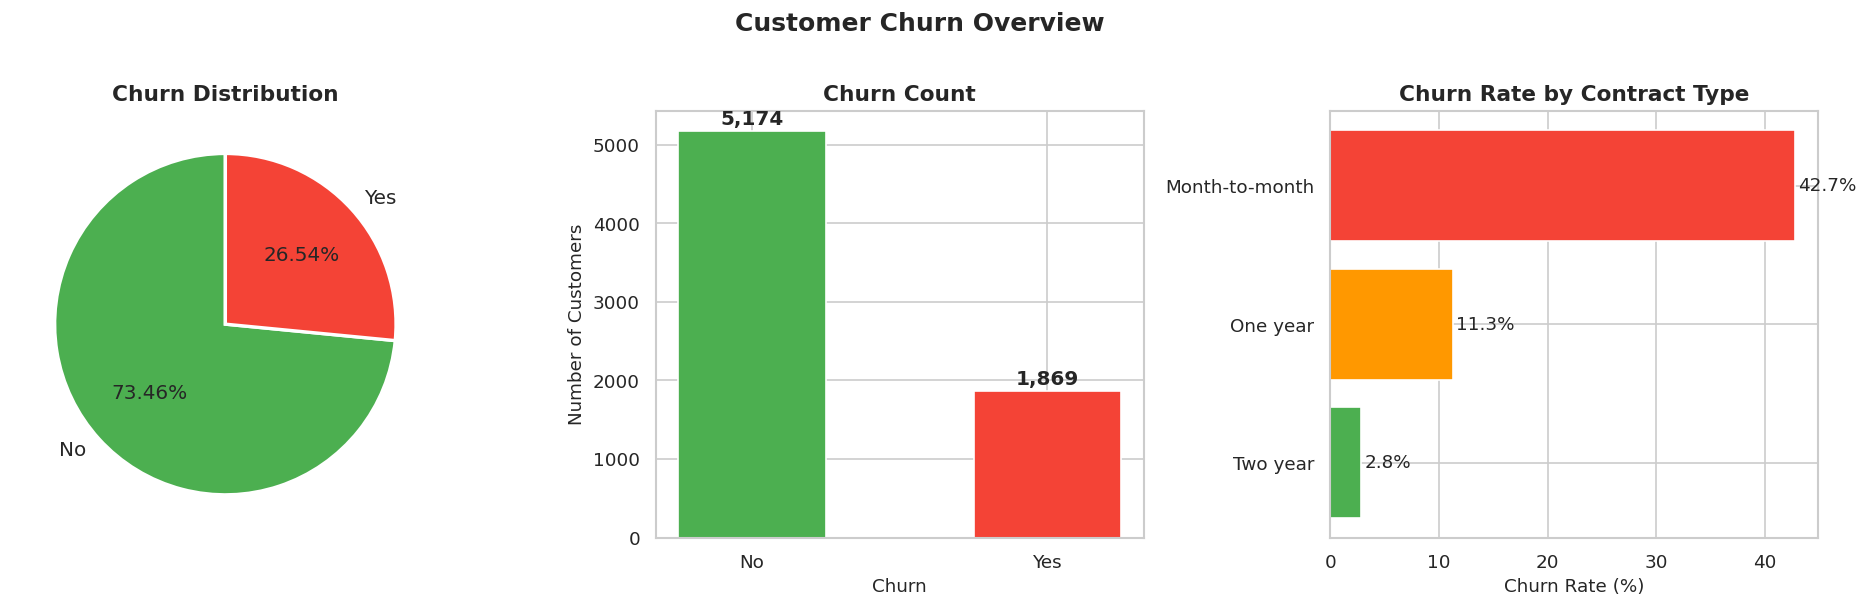


Key Insights:
  Overall churn rate: 26.5%
  Month-to-month customers churn at ~42% vs < 3% on two-year contracts


In [5]:
# Churn distribution
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].pie(
    churn_counts, labels=churn_counts.index,
    autopct='%1.2f%%', startangle=90,
    colors=[CHURN_COLORS.get(k, '#999') for k in churn_counts.index],
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12}
)
axes[0].set_title('Churn Distribution', fontweight='bold')

bars = axes[1].bar(
    churn_counts.index, churn_counts.values,
    color=[CHURN_COLORS.get(k, '#999') for k in churn_counts.index],
    edgecolor='white', width=0.5
)
for bar, v in zip(bars, churn_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 30, f'{v:,}',
                 ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[1].set_title('Churn Count', fontweight='bold')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Number of Customers')

contract_churn = (
    df.groupby('Contract')['Churn']
    .apply(lambda x: (x == 'Yes').sum() / len(x) * 100)
    .sort_values(ascending=True)
)
axes[2].barh(contract_churn.index, contract_churn.values,
             color=['#4CAF50', '#FF9800', '#F44336'], edgecolor='white')
for i, v in enumerate(contract_churn.values):
    axes[2].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=11)
axes[2].set_title('Churn Rate by Contract Type', fontweight='bold')
axes[2].set_xlabel('Churn Rate (%)')

plt.suptitle('Customer Churn Overview', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_churn_overview.png', bbox_inches='tight')
plt.show()

print('\nKey Insights:')
print(f'  Overall churn rate: {churn_pct["Yes"]:.1f}%')
print('  Month-to-month customers churn at ~42% vs < 3% on two-year contracts')

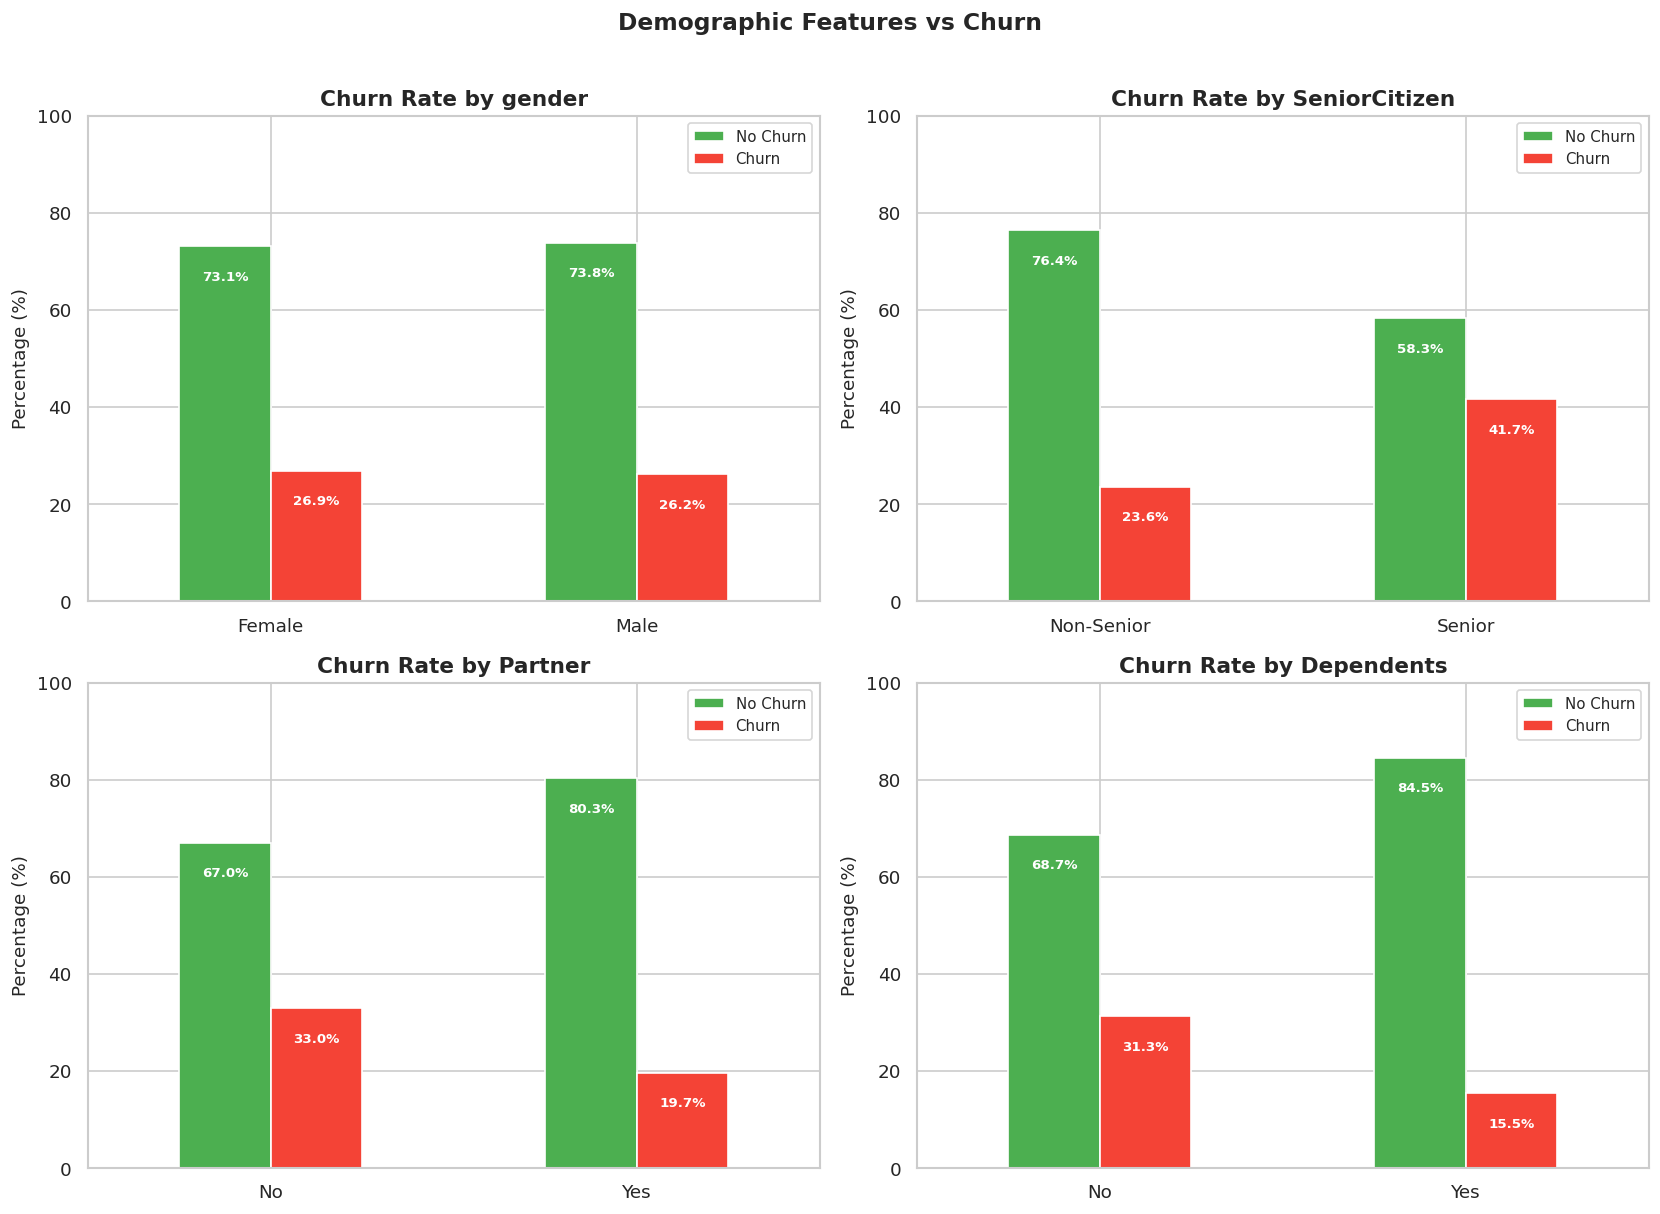


Key Insights:
  Senior citizens churn at ~2x the rate of non-seniors (~42% vs ~24%)
  Customers without a partner or dependents are more likely to churn


In [6]:
# Demographic features vs churn
demo_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(demo_cols):
    ax = axes[i]
    data = df.copy()
    x_col = col
    if col == 'SeniorCitizen':
        data['SeniorCitizen'] = data['SeniorCitizen'].map({0: 'Non-Senior', 1: 'Senior'})
        x_col = 'SeniorCitizen'

    churn_by_col = (
        data.groupby([x_col, 'Churn'])
        .size().unstack(fill_value=0)
        .apply(lambda r: r / r.sum() * 100, axis=1)
    )
    churn_by_col.plot(kind='bar', ax=ax,
                      color=[CHURN_COLORS.get('No','#4CAF50'), CHURN_COLORS.get('Yes','#F44336')],
                      edgecolor='white', rot=0)
    ax.set_title(f'Churn Rate by {x_col}', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Percentage (%)')
    ax.legend(['No Churn', 'Churn'], fontsize=9)
    ax.set_ylim(0, 100)
    for p in ax.patches:
        if p.get_height() > 5:
            ax.annotate(f'{p.get_height():.1f}%',
                        (p.get_x() + p.get_width()/2, p.get_height() - 5),
                        ha='center', va='top', fontsize=8, color='white', fontweight='bold')

plt.suptitle('Demographic Features vs Churn', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_demographics_churn.png', bbox_inches='tight')
plt.show()

print('\nKey Insights:')
print('  Senior citizens churn at ~2x the rate of non-seniors (~42% vs ~24%)')
print('  Customers without a partner or dependents are more likely to churn')

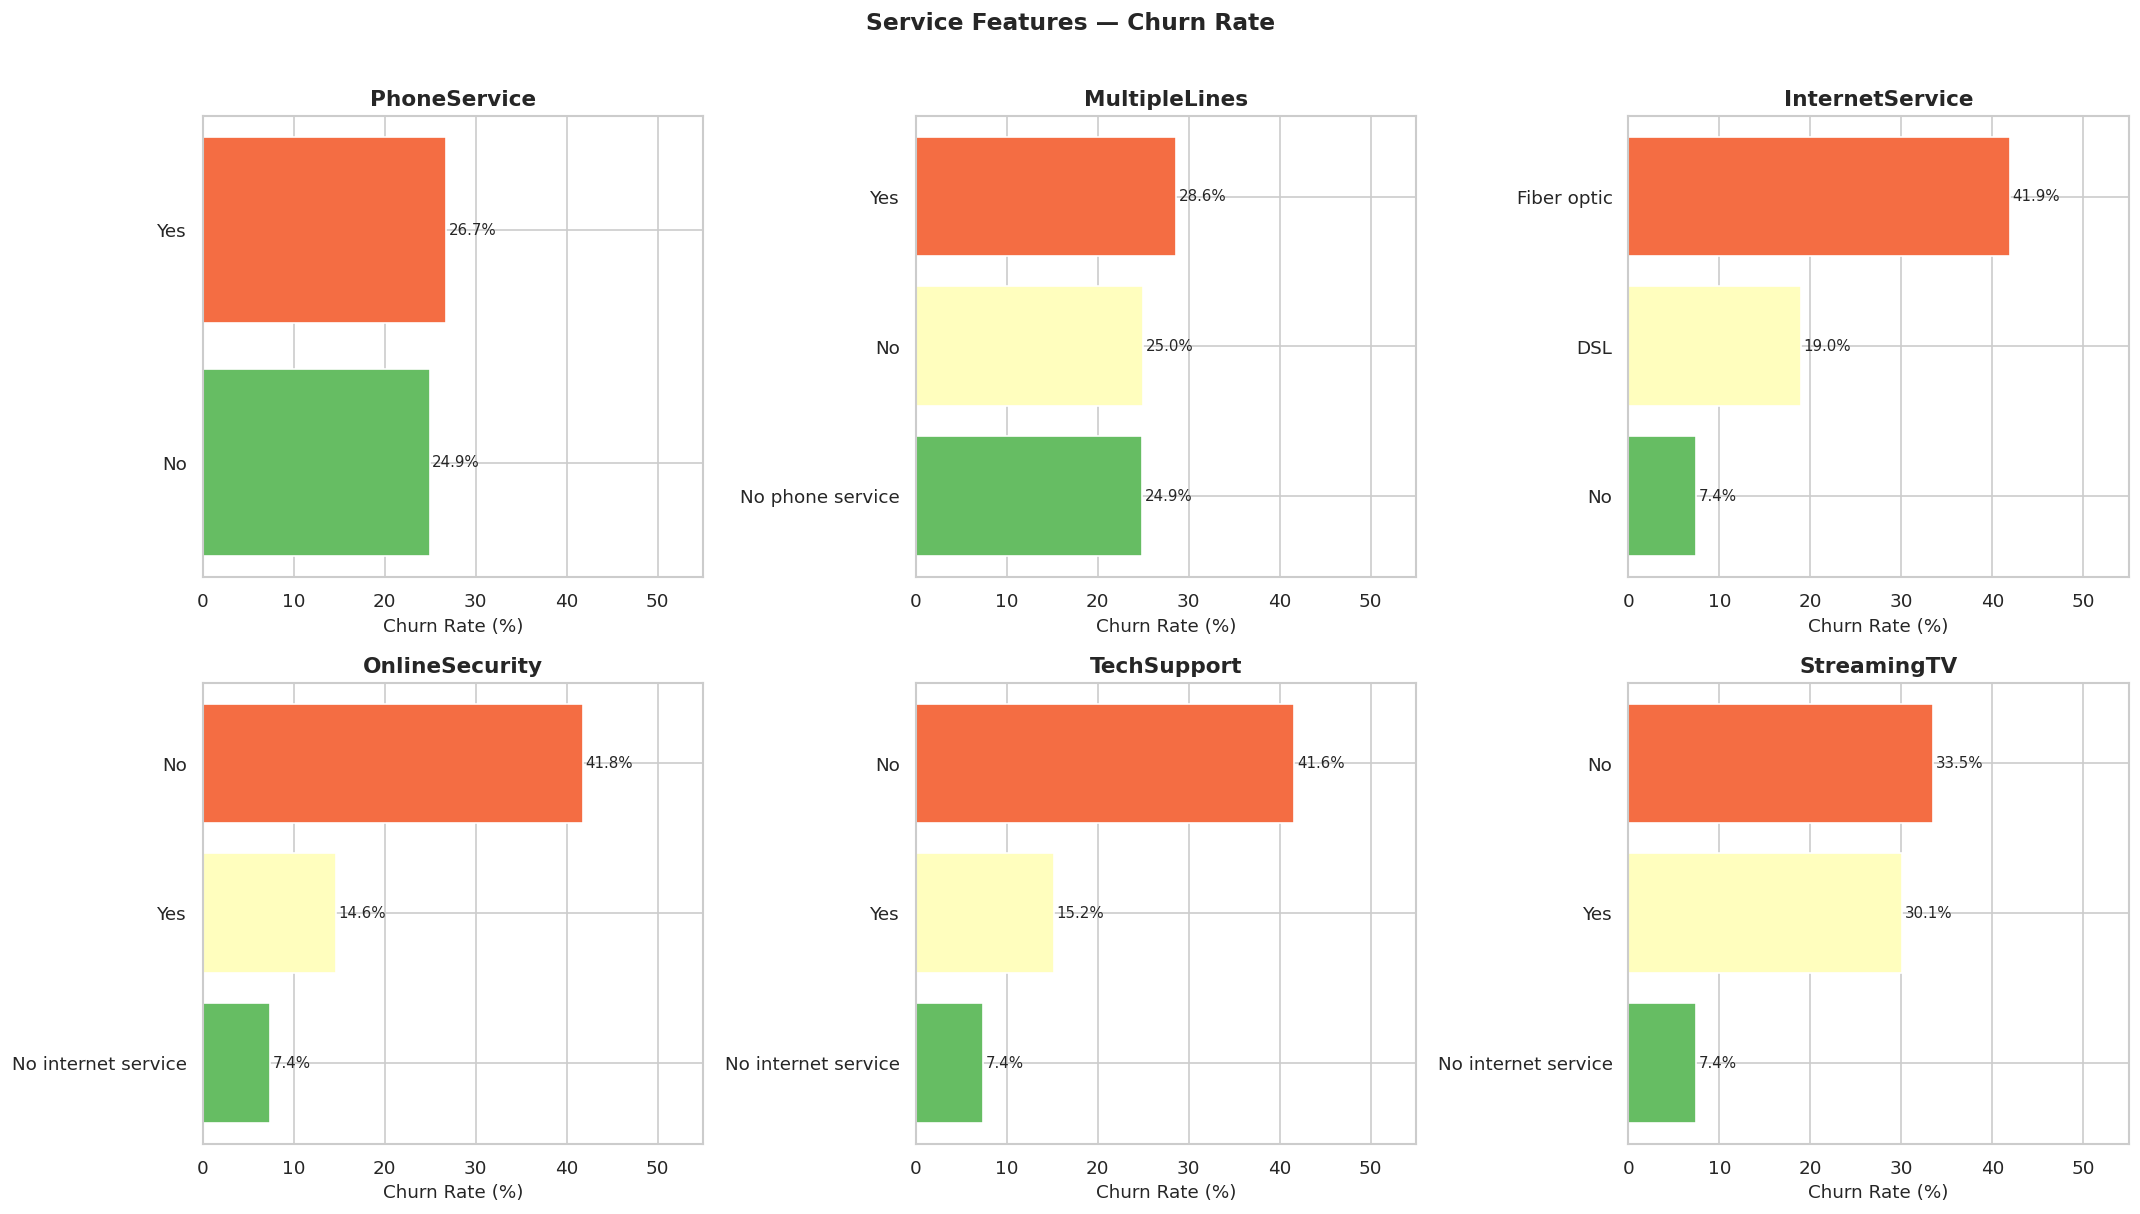


Key Insights:
  Fiber Optic internet customers churn at ~42% -- highest single-feature signal
  Customers without OnlineSecurity or TechSupport churn far more


In [7]:
# Service features vs churn
service_cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'TechSupport', 'StreamingTV'
]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(service_cols):
    ax = axes[i]
    churn_rate = (
        df.groupby(col)['Churn']
        .apply(lambda x: (x == 'Yes').mean() * 100)
        .sort_values(ascending=True)
    )
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(churn_rate)))
    bars = ax.barh(churn_rate.index, churn_rate.values, color=colors, edgecolor='white')
    for bar, val in zip(bars, churn_rate.values):
        ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Churn Rate (%)')
    ax.set_xlim(0, 55)

plt.suptitle('Service Features — Churn Rate', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_services_churn.png', bbox_inches='tight')
plt.show()

print('\nKey Insights:')
print('  Fiber Optic internet customers churn at ~42% -- highest single-feature signal')
print('  Customers without OnlineSecurity or TechSupport churn far more')

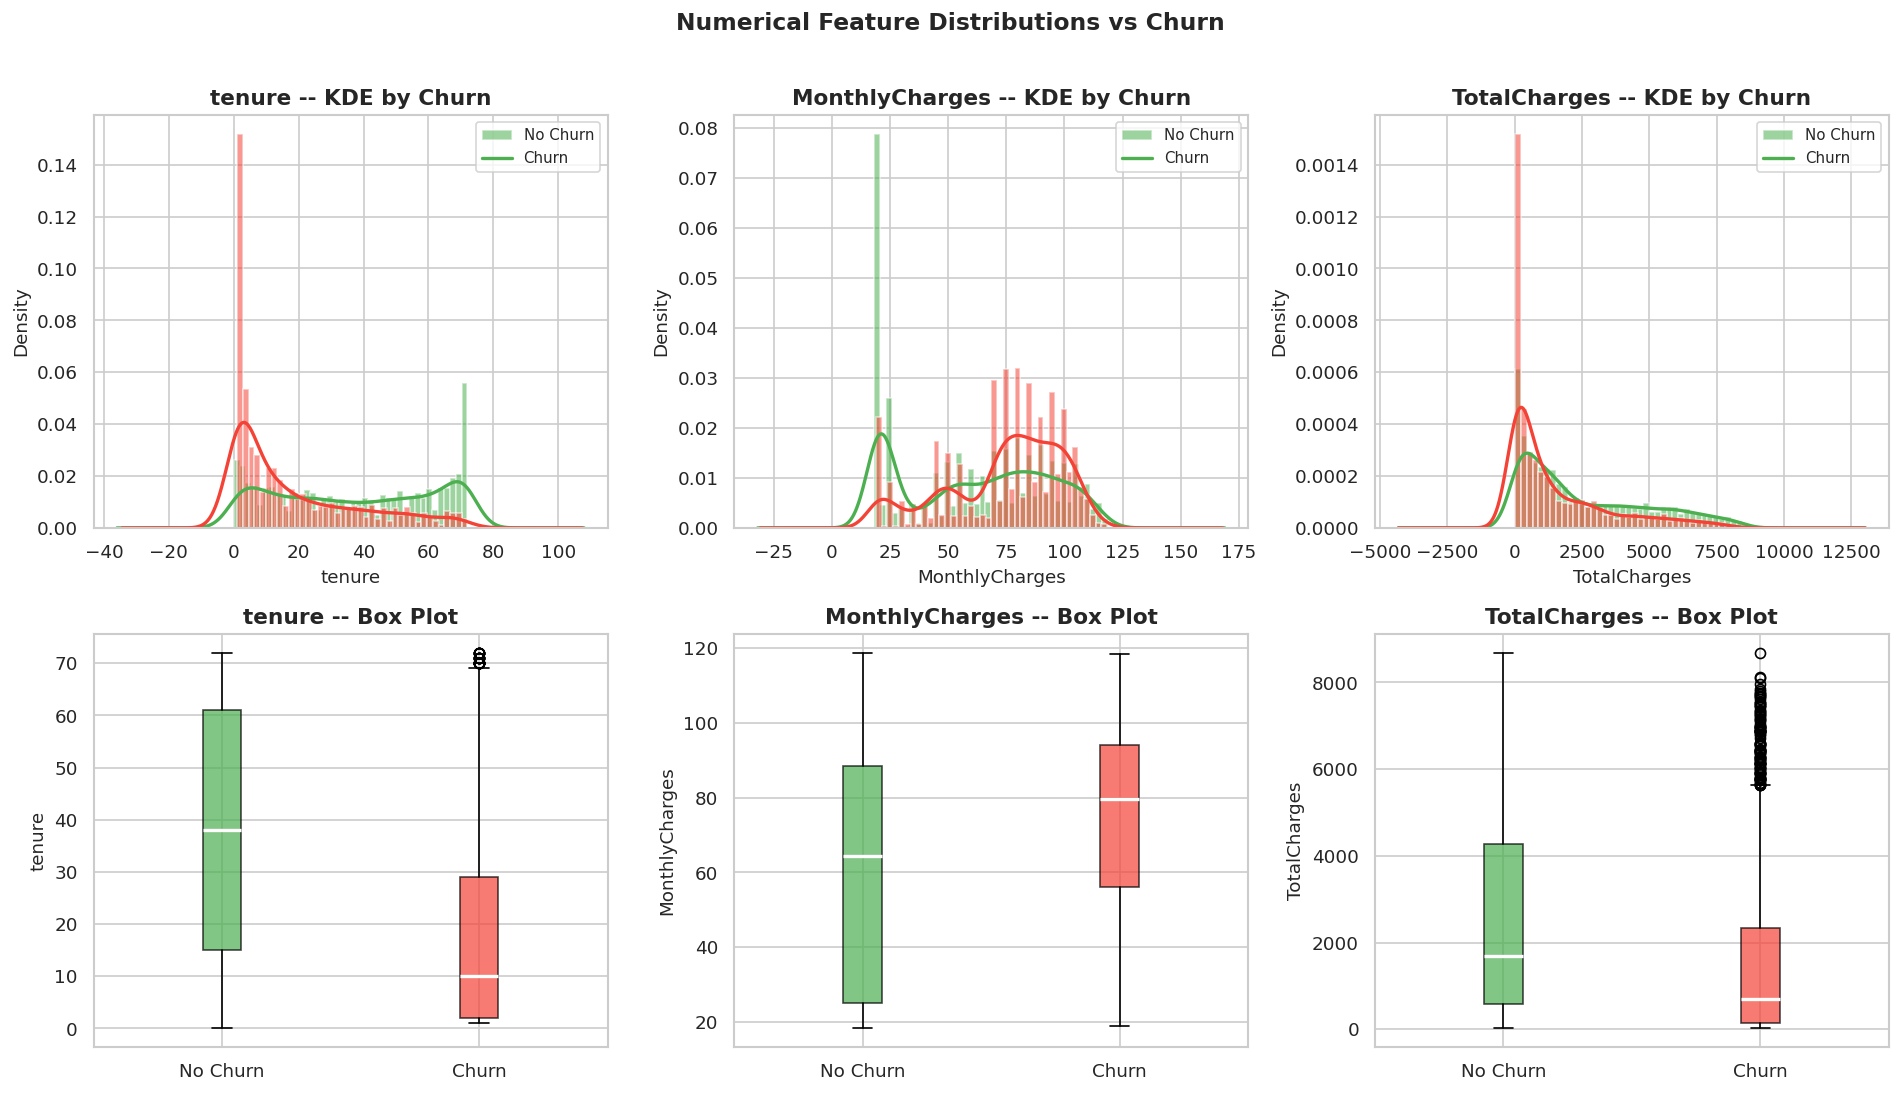


Key Insights:
  Churners have shorter tenure (median ~10 months vs ~38 for loyal customers)
  Churners pay higher monthly charges on average (~$74 vs $61)


In [8]:
# Numerical features
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for i, col in enumerate(num_cols):
    ax = axes[0, i]
    for churn_val, color in [('No', '#4CAF50'), ('Yes', '#F44336')]:
        subset = df[df['Churn'] == churn_val][col].dropna()
        ax.hist(subset, bins=40, alpha=0.55, color=color, density=True, label=churn_val)
        subset.plot.kde(ax=ax, color=color, linewidth=2)
    ax.set_title(f'{col} -- KDE by Churn', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend(['No Churn', 'Churn'], fontsize=9)

    ax2 = axes[1, i]
    data_no  = df[df['Churn'] == 'No'][col].dropna()
    data_yes = df[df['Churn'] == 'Yes'][col].dropna()
    bp = ax2.boxplot([data_no, data_yes], labels=['No Churn', 'Churn'],
                     patch_artist=True, notch=False,
                     medianprops=dict(color='white', linewidth=2))
    for patch, color in zip(bp['boxes'], ['#4CAF50', '#F44336']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax2.set_title(f'{col} -- Box Plot', fontweight='bold')
    ax2.set_ylabel(col)

plt.suptitle('Numerical Feature Distributions vs Churn', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_numerical_features.png', bbox_inches='tight')
plt.show()

print('\nKey Insights:')
print('  Churners have shorter tenure (median ~10 months vs ~38 for loyal customers)')
print('  Churners pay higher monthly charges on average (~$74 vs $61)')

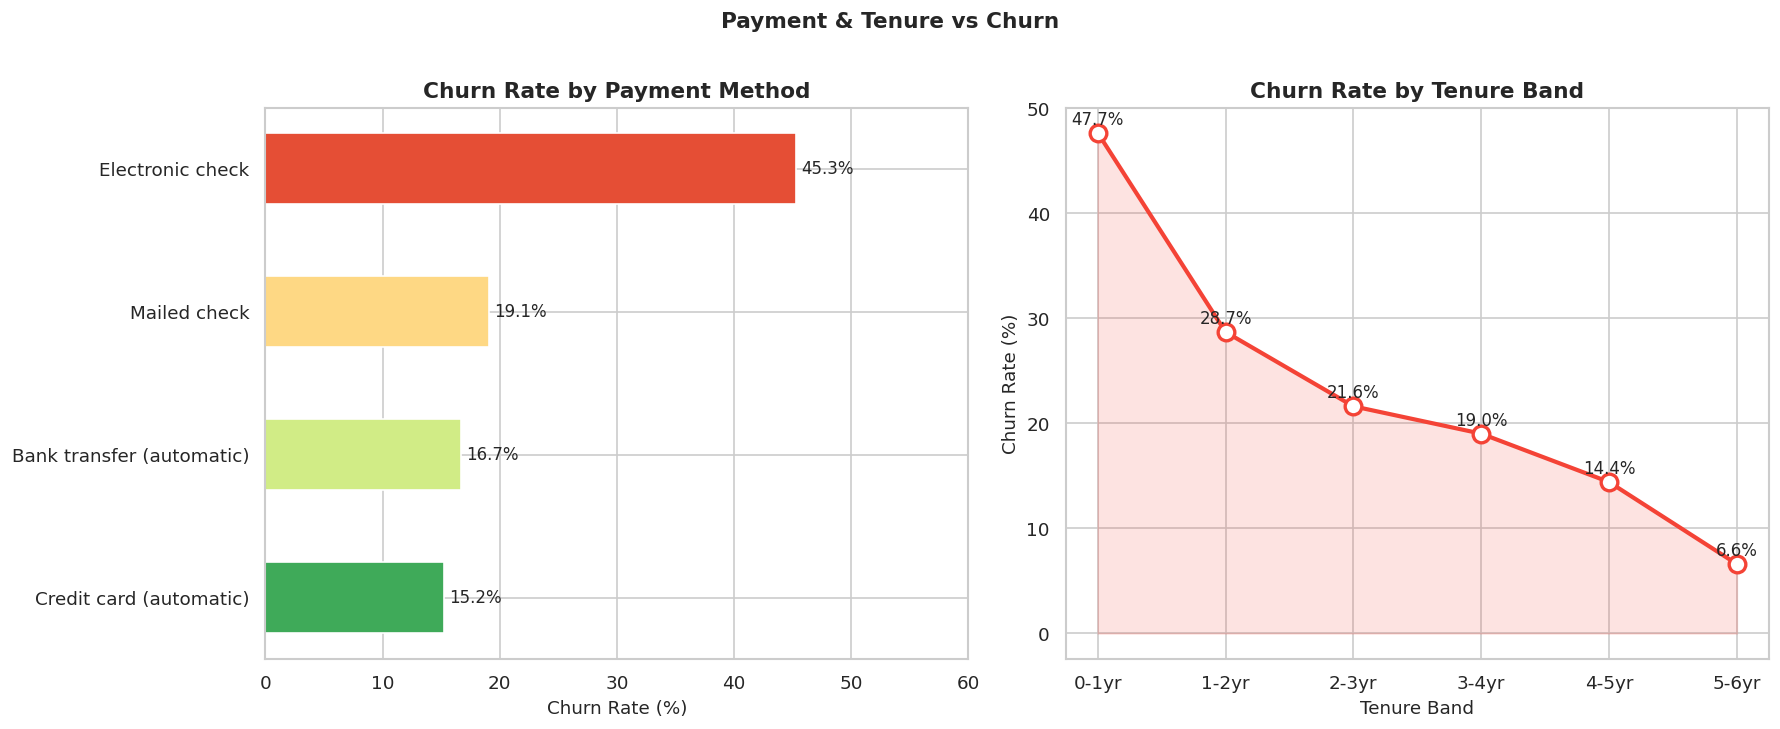


Key Insights:
  Electronic check users churn at ~45% -- highest of all payment methods
  Churn is most severe in the first 12 months (~47% early-life churn)


In [9]:
# Payment method & tenure vs churn
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

pay_churn = (
    df.groupby('PaymentMethod')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=True)
)
colors = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(pay_churn)))
bars = axes[0].barh(pay_churn.index, pay_churn.values, color=colors, edgecolor='white', height=0.5)
for bar, val in zip(bars, pay_churn.values):
    axes[0].text(val + 0.4, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=10)
axes[0].set_title('Churn Rate by Payment Method', fontweight='bold')
axes[0].set_xlabel('Churn Rate (%)')
axes[0].set_xlim(0, 60)

df['tenure_band'] = pd.cut(df['tenure'],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=['0-1yr','1-2yr','2-3yr','3-4yr','4-5yr','5-6yr'], right=True)
tb_churn = (
    df.groupby('tenure_band', observed=True)['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
)
axes[1].plot(range(len(tb_churn)), tb_churn.values, 'o-',
             color='#F44336', linewidth=2.5, markersize=10,
             markerfacecolor='white', markeredgewidth=2)
axes[1].fill_between(range(len(tb_churn)), tb_churn.values, alpha=0.15, color='#F44336')
for x, y in enumerate(tb_churn.values):
    axes[1].annotate(f'{y:.1f}%', (x, y + 0.8), ha='center', fontsize=10)
axes[1].set_xticks(range(len(tb_churn)))
axes[1].set_xticklabels(tb_churn.index)
axes[1].set_title('Churn Rate by Tenure Band', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xlabel('Tenure Band')

plt.suptitle('Payment & Tenure vs Churn', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_payment_tenure.png', bbox_inches='tight')
plt.show()

print('\nKey Insights:')
print('  Electronic check users churn at ~45% -- highest of all payment methods')
print('  Churn is most severe in the first 12 months (~47% early-life churn)')

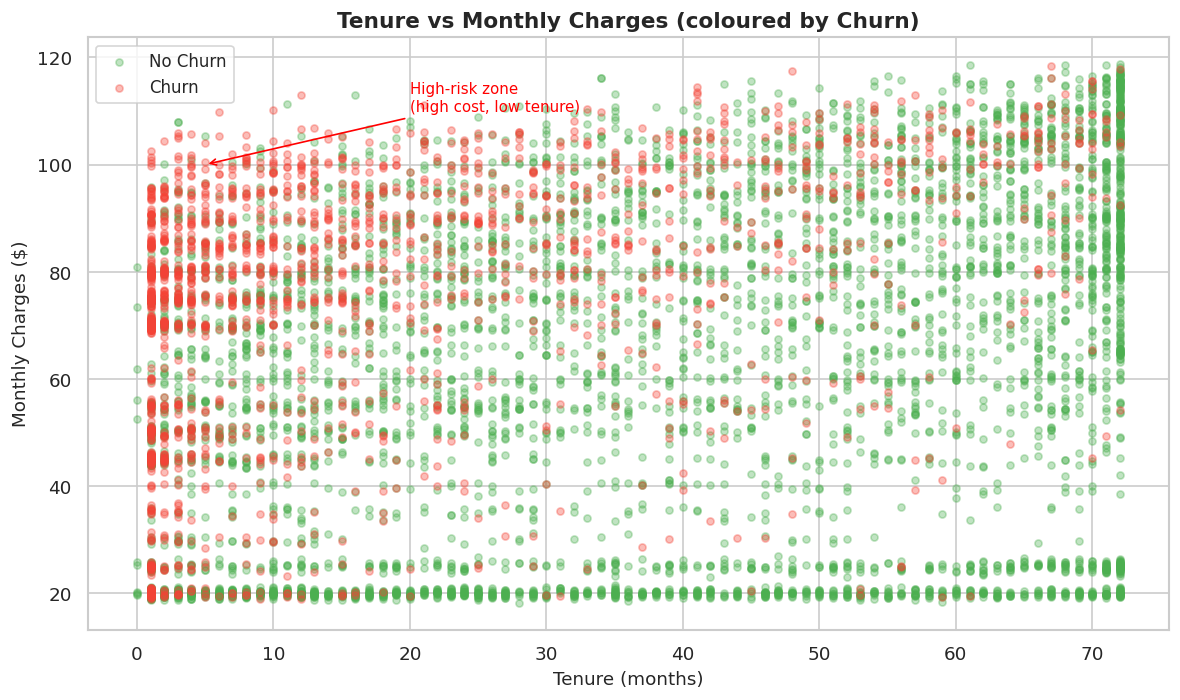

In [10]:
# Tenure vs Monthly Charges scatter
fig, ax = plt.subplots(figsize=(10, 6))
for churn_val, color, label in [('No', '#4CAF50', 'No Churn'), ('Yes', '#F44336', 'Churn')]:
    subset = df[df['Churn'] == churn_val]
    ax.scatter(subset['tenure'], subset['MonthlyCharges'],
               alpha=0.35, s=18, c=color, label=label)
ax.set_title('Tenure vs Monthly Charges (coloured by Churn)', fontweight='bold')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Monthly Charges ($)')
ax.legend(fontsize=10)
ax.annotate('High-risk zone\n(high cost, low tenure)',
            xy=(5, 100), xytext=(20, 110),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=9, color='red')
plt.tight_layout()
plt.savefig('eda_scatter_tenure_charges.png', bbox_inches='tight')
plt.show()

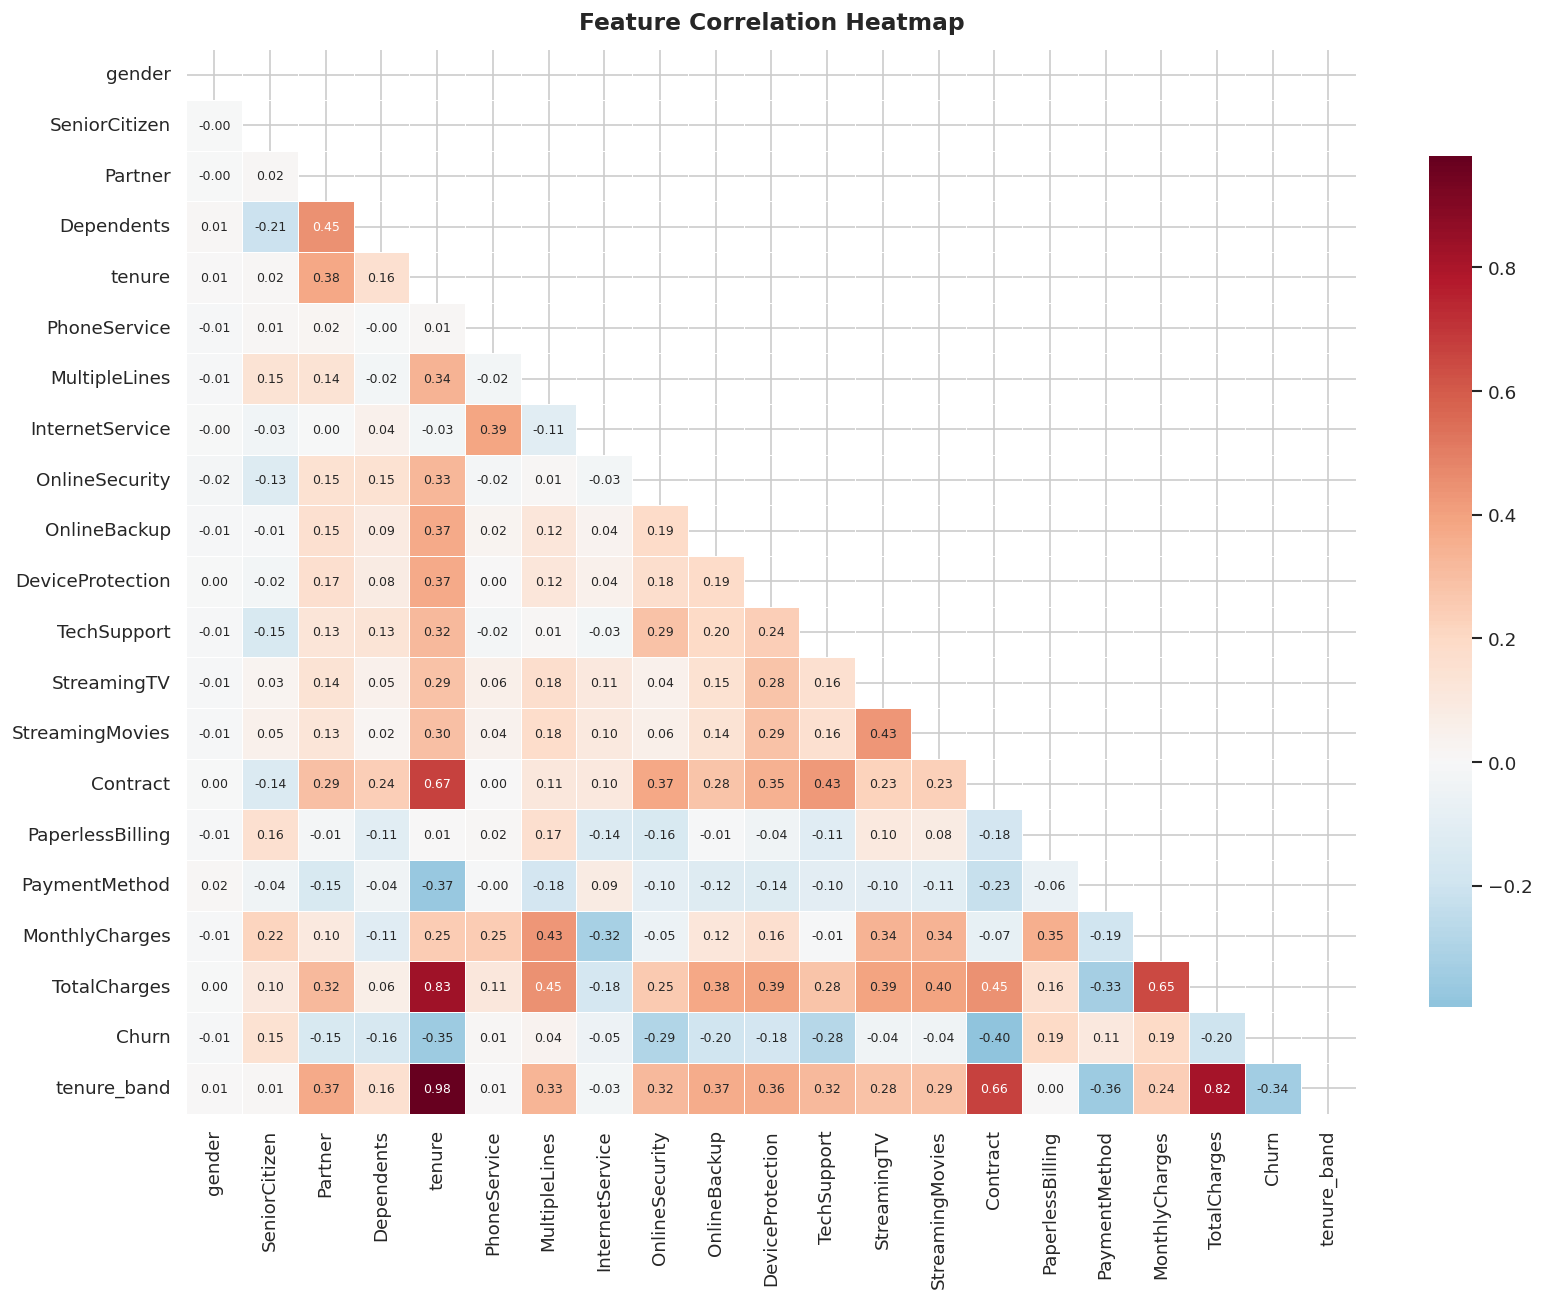

Top 10 features correlated with Churn:
Contract           -0.396713
tenure             -0.352229
tenure_band        -0.341033
OnlineSecurity     -0.289309
TechSupport        -0.282492
TotalCharges       -0.199484
OnlineBackup       -0.195525
MonthlyCharges      0.193356
PaperlessBilling    0.191825
DeviceProtection   -0.178134


In [11]:
# Correlation heatmap
df_enc_temp = df.copy()
for col in df_enc_temp.select_dtypes('object').columns:
    df_enc_temp[col] = LabelEncoder().fit_transform(df_enc_temp[col].astype(str))
try:
    df_enc_temp['tenure_band'] = LabelEncoder().fit_transform(
        df_enc_temp['tenure_band'].astype(str))
except Exception:
    pass

corr = df_enc_temp.drop(columns='customerID', errors='ignore').corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.4,
            annot_kws={'size': 7.5}, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', bbox_inches='tight')
plt.show()

churn_corr = corr['Churn'].drop('Churn').sort_values(key=abs, ascending=False).head(10)
print('Top 10 features correlated with Churn:')
print(churn_corr.to_string())

Data Cleaning & Preprocessing


In [12]:
df_clean = df.copy()

# Fix TotalCharges
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
n_nan = df_clean['TotalCharges'].isna().sum()
df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median(), inplace=True)
print(f'TotalCharges NaN fixed: {n_nan} rows imputed with median')

# Drop identifiers and engineered band
df_clean.drop(columns=['customerID', 'tenure_band'], inplace=True, errors='ignore')

# Encode target
df_clean['Churn'] = (df_clean['Churn'] == 'Yes').astype(int)

# Column groups
binary_cols  = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
multi_cols   = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Label encode binary
le = LabelEncoder()
for col in binary_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

# One-hot encode multi-class
df_clean = pd.get_dummies(df_clean, columns=multi_cols, drop_first=True)

# Split
X = df_clean.drop(columns='Churn')
y = df_clean['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)

# Scale
scaler = StandardScaler()
X_train_sc = X_train.copy()
X_test_sc  = X_test.copy()
X_train_sc[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_sc[numeric_cols]  = scaler.transform(X_test[numeric_cols])

print(f'\nPreprocessing complete.')
print(f'Feature matrix : {X.shape}')
print(f'Train          : {X_train_sc.shape}  (churn={y_train.mean()*100:.1f}%)')
print(f'Test           : {X_test_sc.shape}   (churn={y_test.mean()*100:.1f}%)')

TotalCharges NaN fixed: 11 rows imputed with median

Preprocessing complete.
Feature matrix : (7043, 30)
Train          : (5634, 30)  (churn=26.5%)
Test           : (1409, 30)   (churn=26.5%)


Feature Engineering



In [13]:
def engineer_features(df_in):
    df_fe = df_in.copy()
    t  = df_fe['tenure'].values
    mc = df_fe['MonthlyCharges'].values
    tc = df_fe['TotalCharges'].values
    df_fe['avg_monthly_spend']   = tc / (t + 1)
    df_fe['charge_ratio']        = mc / (tc + 1)
    df_fe['is_new_customer']     = (t <= 12).astype(int)
    df_fe['high_monthly_charge'] = (mc > np.percentile(mc, 75)).astype(int)
    return df_fe


X_train_fe = engineer_features(X_train.copy())
X_test_fe  = engineer_features(X_test.copy())

# Re-scale continuous columns including new engineered ones
fe_scale_cols = numeric_cols + ['avg_monthly_spend', 'charge_ratio']
scaler_fe = StandardScaler()
X_train_fe[fe_scale_cols] = scaler_fe.fit_transform(X_train_fe[fe_scale_cols])
X_test_fe[fe_scale_cols]  = scaler_fe.transform(X_test_fe[fe_scale_cols])

fe_new = ['avg_monthly_spend', 'charge_ratio', 'is_new_customer', 'high_monthly_charge']
print(f'Feature engineering done. Shape: {X_train_fe.shape}')
print(f'New features: {fe_new}')

Feature engineering done. Shape: (5634, 34)
New features: ['avg_monthly_spend', 'charge_ratio', 'is_new_customer', 'high_monthly_charge']


Handling Class Imbalance

The dataset has ~26.5% churn (minority class). We address this three ways:
- **SMOTE** - synthetic minority oversampling
- **Random OverSampler** - simple duplication of minority rows
- **Class weights** - built into model parameters

Class distribution after resampling:
  Original  : {0: np.int64(4139), 1: np.int64(1495)}
  SMOTE     : {0: np.int64(4139), 1: np.int64(4139)}
  RandomOS  : {0: np.int64(4139), 1: np.int64(4139)}


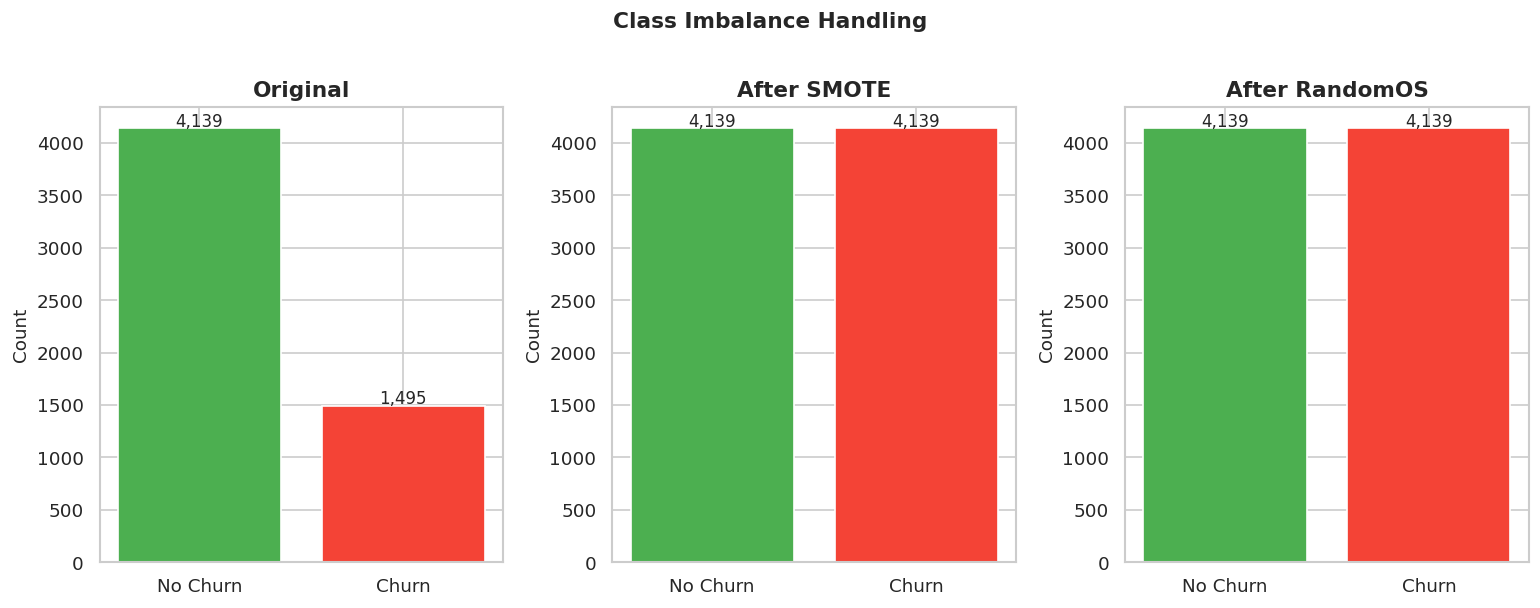

In [14]:
smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_fe, y_train)

ros = RandomOverSampler(random_state=SEED)
X_train_ros, y_train_ros = ros.fit_resample(X_train_fe, y_train)

print('Class distribution after resampling:')
print(f'  Original  : {dict(y_train.value_counts())}')
print(f'  SMOTE     : {dict(pd.Series(y_train_sm).value_counts())}')
print(f'  RandomOS  : {dict(pd.Series(y_train_ros).value_counts())}')

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
datasets = [
    ('Original',       y_train),
    ('After SMOTE',    pd.Series(y_train_sm)),
    ('After RandomOS', pd.Series(y_train_ros))
]
for ax, (title, y_s) in zip(axes, datasets):
    vc = y_s.value_counts()
    ax.bar(['No Churn', 'Churn'], [vc.get(0, 0), vc.get(1, 0)],
           color=['#4CAF50', '#F44336'], edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    for i, v in enumerate([vc.get(0, 0), vc.get(1, 0)]):
        ax.text(i, v + 20, f'{v:,}', ha='center', fontsize=10)

plt.suptitle('Class Imbalance Handling', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('class_imbalance_handling.png', bbox_inches='tight')
plt.show()

Machine Learning Models

Four classifiers trained on SMOTE-balanced data:
- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

In [15]:
pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

models_ml = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000, solver='lbfgs',
        class_weight='balanced', random_state=SEED
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=8, min_samples_leaf=20,
        class_weight='balanced', random_state=SEED
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_leaf=5,
        class_weight='balanced', random_state=SEED, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=pos_weight,
        eval_metric='logloss', use_label_encoder=False,
        random_state=SEED, n_jobs=-1
    )
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results_ml = {}

for name, model in models_ml.items():
    print(f'Training {name}...', end=' ', flush=True)
    model.fit(X_train_sm, y_train_sm)

    y_pred  = model.predict(X_test_fe)
    y_proba = model.predict_proba(X_test_fe)[:, 1]
    cv_auc  = cross_val_score(model, X_train_sm, y_train_sm,
                               cv=cv, scoring='roc_auc', n_jobs=-1).mean()

    results_ml[name] = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'F1 Score' : f1_score(y_test, y_pred),
        'ROC-AUC'  : roc_auc_score(y_test, y_proba),
        'CV-AUC'   : cv_auc,
        'y_pred'   : y_pred,
        'y_proba'  : y_proba
    }
    print(f'done  AUC={results_ml[name]["ROC-AUC"]:.4f}  CV-AUC={cv_auc:.4f}')

print('\nAll ML models trained.')

Training Logistic Regression... done  AUC=0.8283  CV-AUC=0.8868
Training Decision Tree... done  AUC=0.8159  CV-AUC=0.8491
Training Random Forest... done  AUC=0.8376  CV-AUC=0.8906
Training XGBoost... done  AUC=0.8212  CV-AUC=0.9039

All ML models trained.


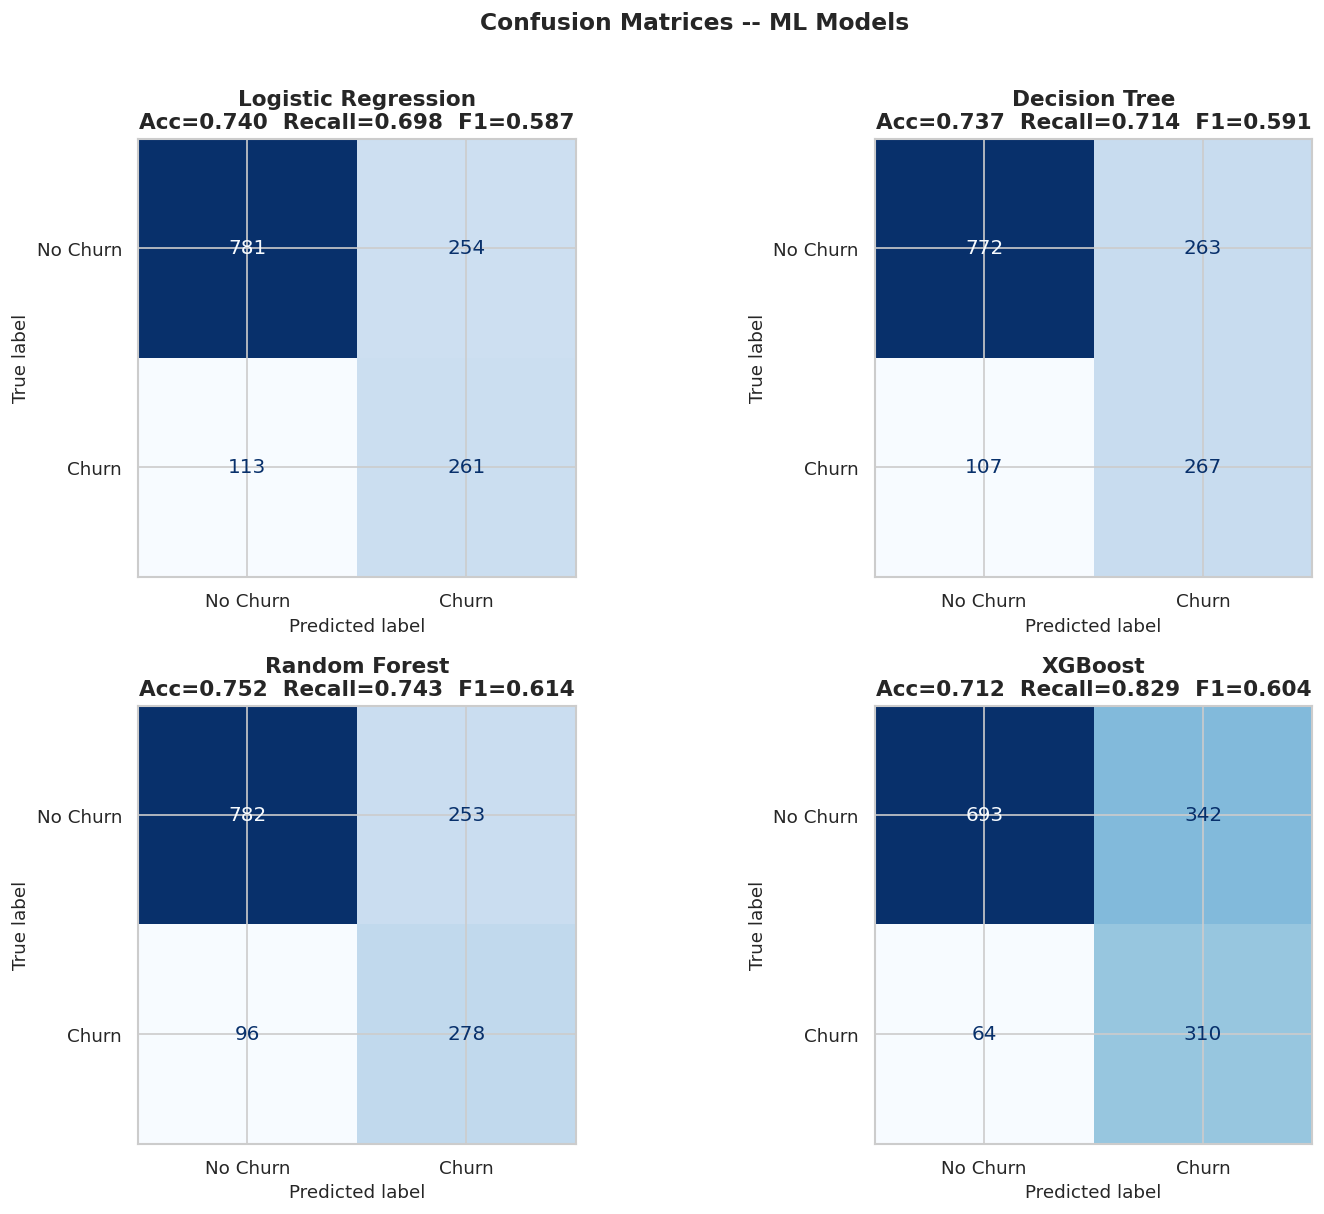

In [17]:
# Confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for i, (name, res) in enumerate(results_ml.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(
        ax=axes[i], cmap='Blues', colorbar=False
    )
    axes[i].set_title(
        f'{name}\nAcc={res["Accuracy"]:.3f}  Recall={res["Recall"]:.3f}  F1={res["F1 Score"]:.3f}',
        fontweight='bold'
    )

plt.suptitle('Confusion Matrices -- ML Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('ml_confusion_matrices.png', bbox_inches='tight')
plt.show()

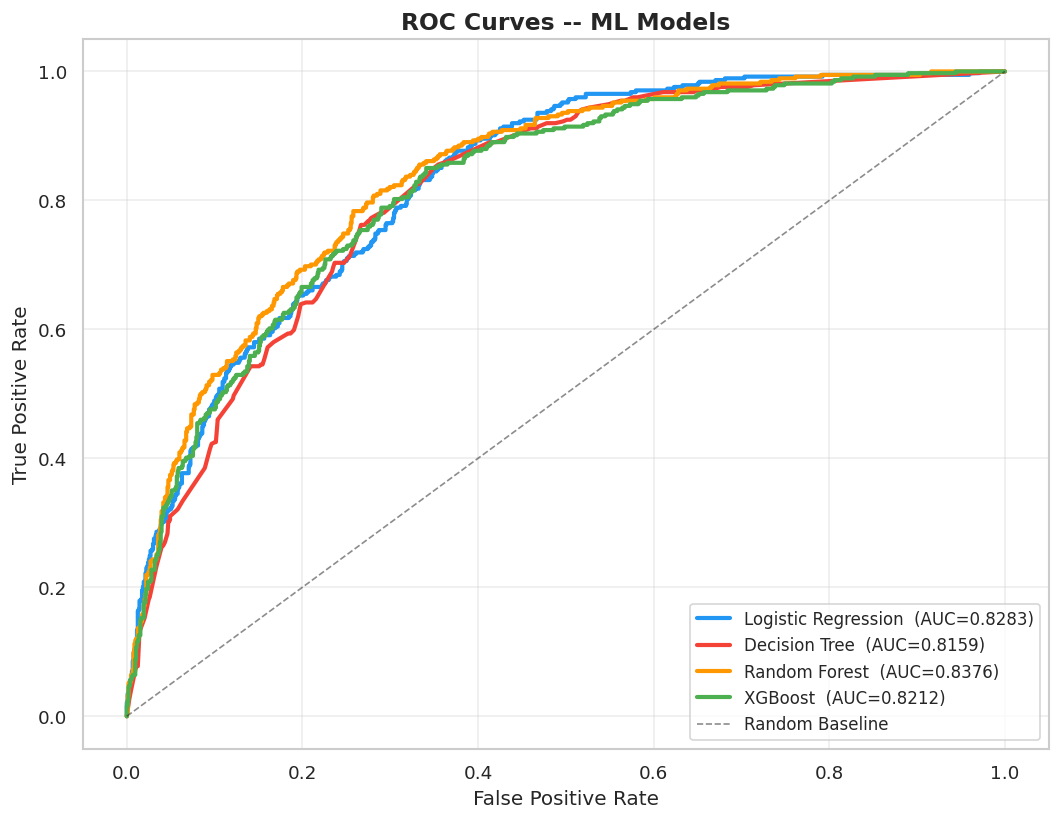

In [18]:
# ROC Curves
fig, ax = plt.subplots(figsize=(9, 7))
for (name, res), color in zip(results_ml.items(), PALETTE):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f"{name}  (AUC={res['ROC-AUC']:.4f})")
ax.plot([0,1],[0,1],'k--',linewidth=1,alpha=0.5,label='Random Baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves -- ML Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig('ml_roc_curves.png', bbox_inches='tight')
plt.show()

In [19]:
for name, res in results_ml.items():
    print(f'\n{"-"*52}')
    print(f'  {name}')
    print(f'{"-"*52}')
    print(classification_report(y_test, res['y_pred'],
                                target_names=['No Churn', 'Churn']))


----------------------------------------------------
  Logistic Regression
----------------------------------------------------
              precision    recall  f1-score   support

    No Churn       0.87      0.75      0.81      1035
       Churn       0.51      0.70      0.59       374

    accuracy                           0.74      1409
   macro avg       0.69      0.73      0.70      1409
weighted avg       0.78      0.74      0.75      1409


----------------------------------------------------
  Decision Tree
----------------------------------------------------
              precision    recall  f1-score   support

    No Churn       0.88      0.75      0.81      1035
       Churn       0.50      0.71      0.59       374

    accuracy                           0.74      1409
   macro avg       0.69      0.73      0.70      1409
weighted avg       0.78      0.74      0.75      1409


----------------------------------------------------
  Random Forest
------------------------

Deep Learning -- Artificial Neural Network (ANN)



In [20]:
n_features = X_train_sm.shape[1]

def build_ann(n_features):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(n_features,),
              kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        BatchNormalization(),
        Dropout(0.35),
        Dense(64, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        BatchNormalization(),
        Dropout(0.25),
        Dense(32, activation='relu'),
        Dropout(0.15),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    return model

ann_model = build_ann(n_features)
ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,617 (61.00 KB)

 Trainable params: 15,233 (59.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [21]:
cw = {0: 1.0, 1: float((y_train_sm == 0).sum()) / max((y_train_sm == 1).sum(), 1)}

callbacks_ann = [
    EarlyStopping(monitor='val_auc', patience=10, mode='max',
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
]

history_ann = ann_model.fit(
    X_train_sm, y_train_sm,
    epochs=80,
    batch_size=128,
    validation_split=0.15,
    class_weight=cw,
    callbacks=callbacks_ann,
    verbose=1
)
print('\nANN training complete.')

Epoch 1/80
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.7172 - auc: 0.7821 - loss: 0.5777 - precision: 0.6657 - recall: 0.6289 - val_accuracy: 0.7448 - val_auc: 0.0000e+00 - val_loss: 0.6210 - val_precision: 1.0000 - val_recall: 0.7448 - learning_rate: 0.0010
Epoch 2/80
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7526 - auc: 0.8265 - loss: 0.5212 - precision: 0.7001 - recall: 0.6980 - val_accuracy: 0.7834 - val_auc: 0.0000e+00 - val_loss: 0.6045 - val_precision: 1.0000 - val_recall: 0.7834 - learning_rate: 0.0010
Epoch 3/80
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7588 - auc: 0.8368 - loss: 0.5054 - precision: 0.7048 - recall: 0.7128 - val_accuracy: 0.7633 - val_auc: 0.0000e+00 - val_loss: 0.5886 - val_precision: 1.0000 - val_recall: 0.7633 - learning_rate: 0.0010
Epoch 4/80
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7648 - auc: 0.8464 - loss: 0.4910 - precision: 0.7125 - recall: 0.7187 - val_accuracy: 0.7560 - val_auc: 0.0000e+00 - val_loss: 0.5

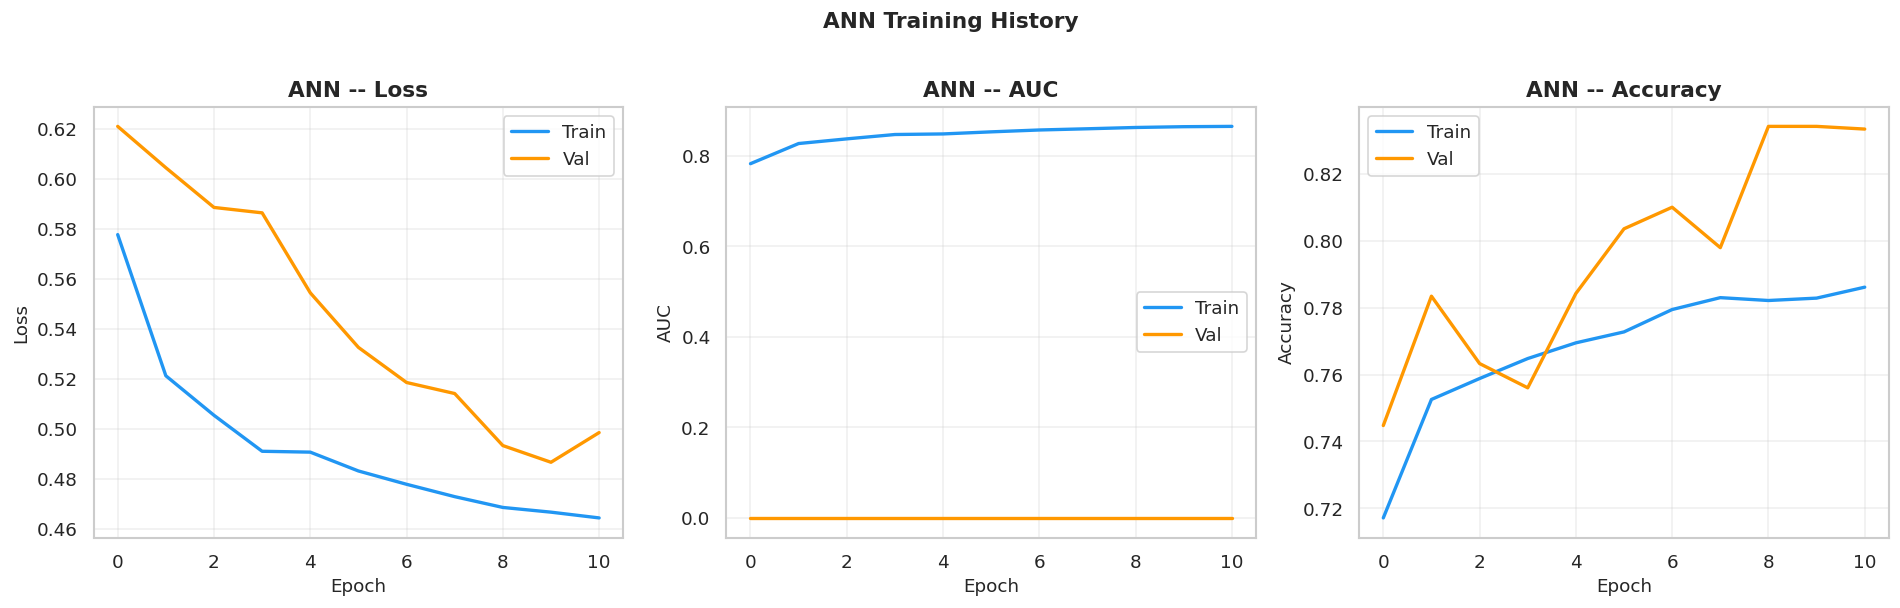

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric, label in zip(axes, ['loss','auc','accuracy'], ['Loss','AUC','Accuracy']):
    ax.plot(history_ann.history[metric],         label='Train', color='#2196F3', linewidth=2)
    ax.plot(history_ann.history[f'val_{metric}'],label='Val',   color='#FF9800', linewidth=2)
    ax.set_title(f'ANN -- {label}', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(label)
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle('ANN Training History', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('ann_training_history.png', bbox_inches='tight')
plt.show()

ANN Results (threshold=0.38):
  Accuracy    : 0.5429
  Precision   : 0.3636
  Recall      : 0.9626
  F1 Score    : 0.5279
  ROC-AUC     : 0.8341

              precision    recall  f1-score   support

    No Churn       0.97      0.39      0.56      1035
       Churn       0.36      0.96      0.53       374

    accuracy                           0.54      1409
   macro avg       0.67      0.68      0.54      1409
weighted avg       0.81      0.54      0.55      1409



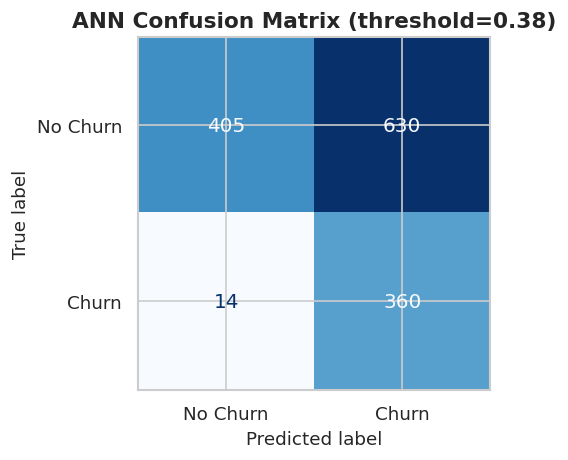

In [23]:
ann_proba = ann_model.predict(X_test_fe, verbose=0).flatten()
THRESHOLD = 0.38
ann_pred  = (ann_proba >= THRESHOLD).astype(int)

results_ann = {
    'Accuracy' : accuracy_score(y_test, ann_pred),
    'Precision': precision_score(y_test, ann_pred, zero_division=0),
    'Recall'   : recall_score(y_test, ann_pred, zero_division=0),
    'F1 Score' : f1_score(y_test, ann_pred, zero_division=0),
    'ROC-AUC'  : roc_auc_score(y_test, ann_proba),
    'y_pred'   : ann_pred,
    'y_proba'  : ann_proba
}

print(f'ANN Results (threshold={THRESHOLD}):')
for k, v in results_ann.items():
    if isinstance(v, float):
        print(f'  {k:<12}: {v:.4f}')
print()
print(classification_report(y_test, ann_pred, target_names=['No Churn', 'Churn']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, ann_pred),
    display_labels=['No Churn', 'Churn']
).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'ANN Confusion Matrix (threshold={THRESHOLD})', fontweight='bold')
plt.tight_layout()
plt.savefig('ann_confusion_matrix.png', bbox_inches='tight')
plt.show()

Model Comparison & Best Model Selection

In [24]:
metric_keys = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']

all_results = {name: {k: v for k, v in res.items() if k in metric_keys}
               for name, res in results_ml.items()}
all_results['ANN'] = {k: v for k, v in results_ann.items() if k in metric_keys}

results_df = pd.DataFrame(all_results).T[metric_keys]
results_df = results_df.sort_values('ROC-AUC', ascending=False)

print('=' * 70)
print('  MODEL COMPARISON TABLE')
print('=' * 70)
display(
    results_df.style
    .format('{:.4f}')
    .background_gradient(cmap='YlGn', subset=metric_keys)
    .set_caption('All metrics on held-out 20% test set')
)

best_name = results_df['ROC-AUC'].idxmax()
print(f'\nBest model by ROC-AUC: {best_name}')
for k in metric_keys:
    print(f'  {k:<12}: {results_df.loc[best_name, k]:.4f}')

  MODEL COMPARISON TABLE


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Random Forest,0.7523,0.5235,0.7433,0.6144,0.8376
ANN,0.5429,0.3636,0.9626,0.5279,0.8341
Logistic Regression,0.7395,0.5068,0.6979,0.5872,0.8283
XGBoost,0.7119,0.4755,0.8289,0.6043,0.8212
Decision Tree,0.7374,0.5038,0.7139,0.5907,0.8159



Best model by ROC-AUC: Random Forest
  Accuracy    : 0.7523
  Precision   : 0.5235
  Recall      : 0.7433
  F1 Score    : 0.6144
  ROC-AUC     : 0.8376


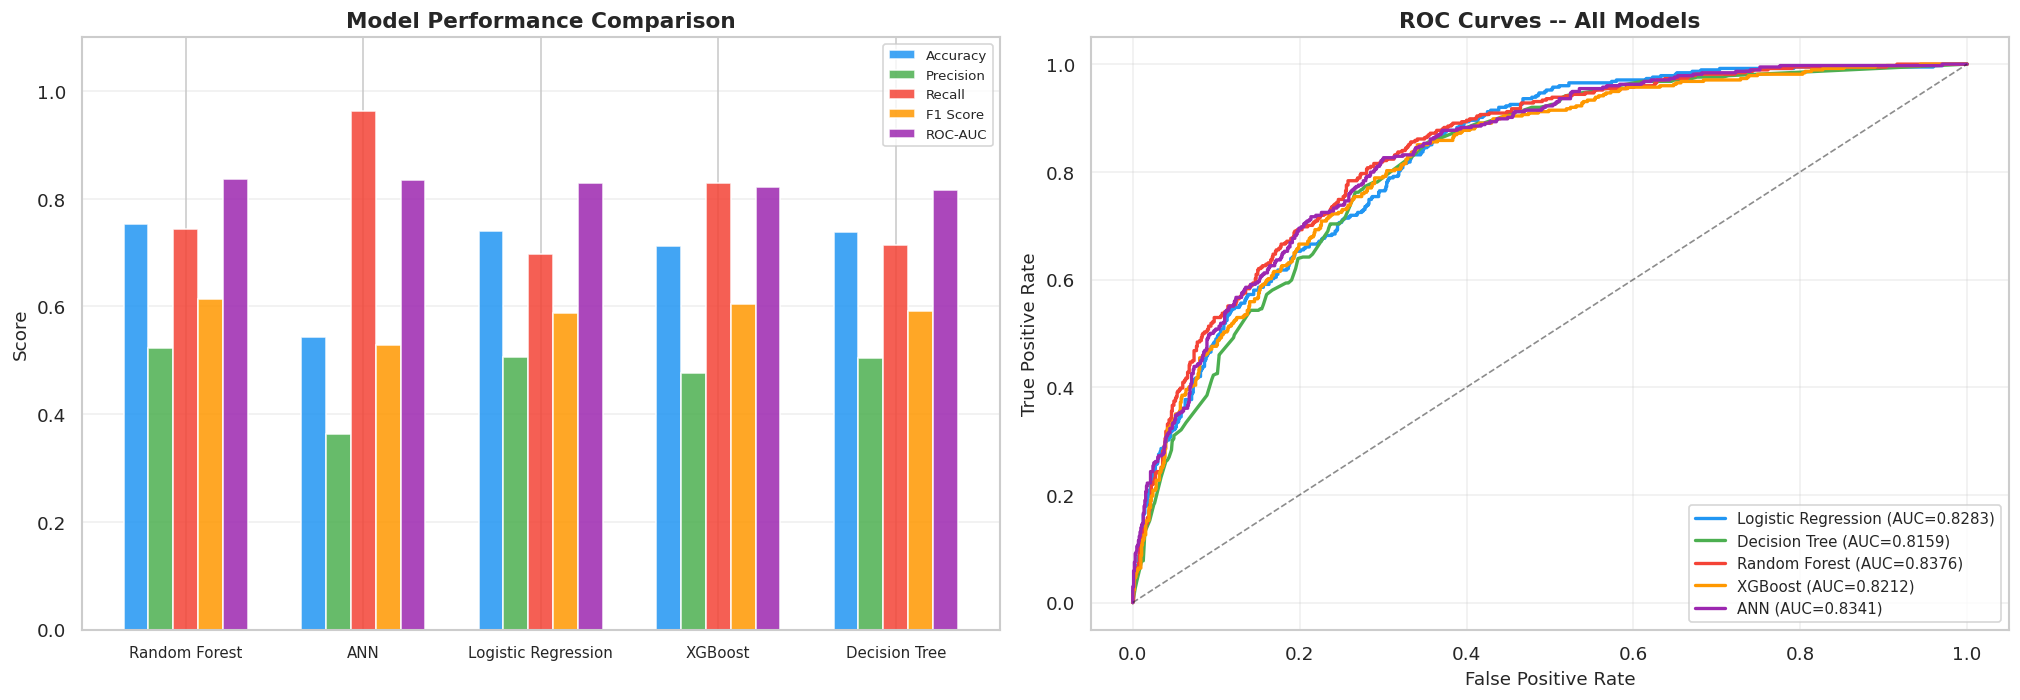

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

x     = np.arange(len(results_df))
width = 0.14
colors = ['#2196F3', '#4CAF50', '#F44336', '#FF9800', '#9C27B0']

for i, (metric, color) in enumerate(zip(metric_keys, colors)):
    offset = (i - len(metric_keys)/2) * width + width/2
    axes[0].bar(x + offset, results_df[metric], width,
                label=metric, color=color, alpha=0.85, edgecolor='white')

axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df.index, fontsize=9)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison', fontweight='bold')
axes[0].legend(fontsize=8, loc='upper right')
axes[0].grid(axis='y', alpha=0.3)

all_probas = {n: r['y_proba'] for n, r in results_ml.items()}
all_probas['ANN'] = results_ann['y_proba']

for (name, proba), color in zip(all_probas.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[1].plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc:.4f})')

axes[1].plot([0,1],[0,1],'k--',linewidth=1,alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves -- All Models', fontweight='bold')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison_all.png', bbox_inches='tight')
plt.show()

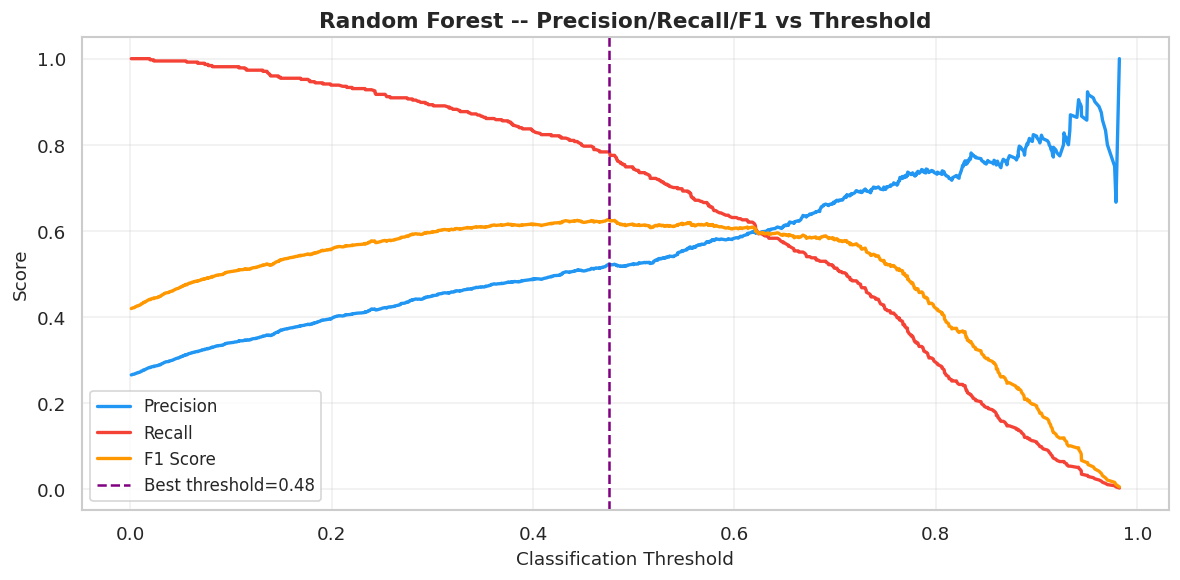

Optimal threshold for Random Forest: 0.476
F1 at optimal threshold: 0.6274


In [26]:
# Threshold tuning for best model
best_proba = all_probas.get(best_name, all_probas['Random Forest'])
prec_vals, rec_vals, thresholds = precision_recall_curve(y_test, best_proba)
f1_vals = 2 * prec_vals * rec_vals / (prec_vals + rec_vals + 1e-9)
best_thresh_idx = np.argmax(f1_vals)
best_thresh = thresholds[best_thresh_idx] if best_thresh_idx < len(thresholds) else 0.5

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, prec_vals[:-1], '#2196F3', linewidth=2, label='Precision')
ax.plot(thresholds, rec_vals[:-1],  '#F44336',  linewidth=2, label='Recall')
ax.plot(thresholds, f1_vals[:-1],   '#FF9800',  linewidth=2, label='F1 Score')
ax.axvline(best_thresh, color='purple', linestyle='--', linewidth=1.5,
           label=f'Best threshold={best_thresh:.2f}')
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Score')
ax.set_title(f'{best_name} -- Precision/Recall/F1 vs Threshold', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_tuning.png', bbox_inches='tight')
plt.show()

print(f'Optimal threshold for {best_name}: {best_thresh:.3f}')
print(f'F1 at optimal threshold: {f1_vals[best_thresh_idx]:.4f}')

Feature Importance & SHAP Explainability

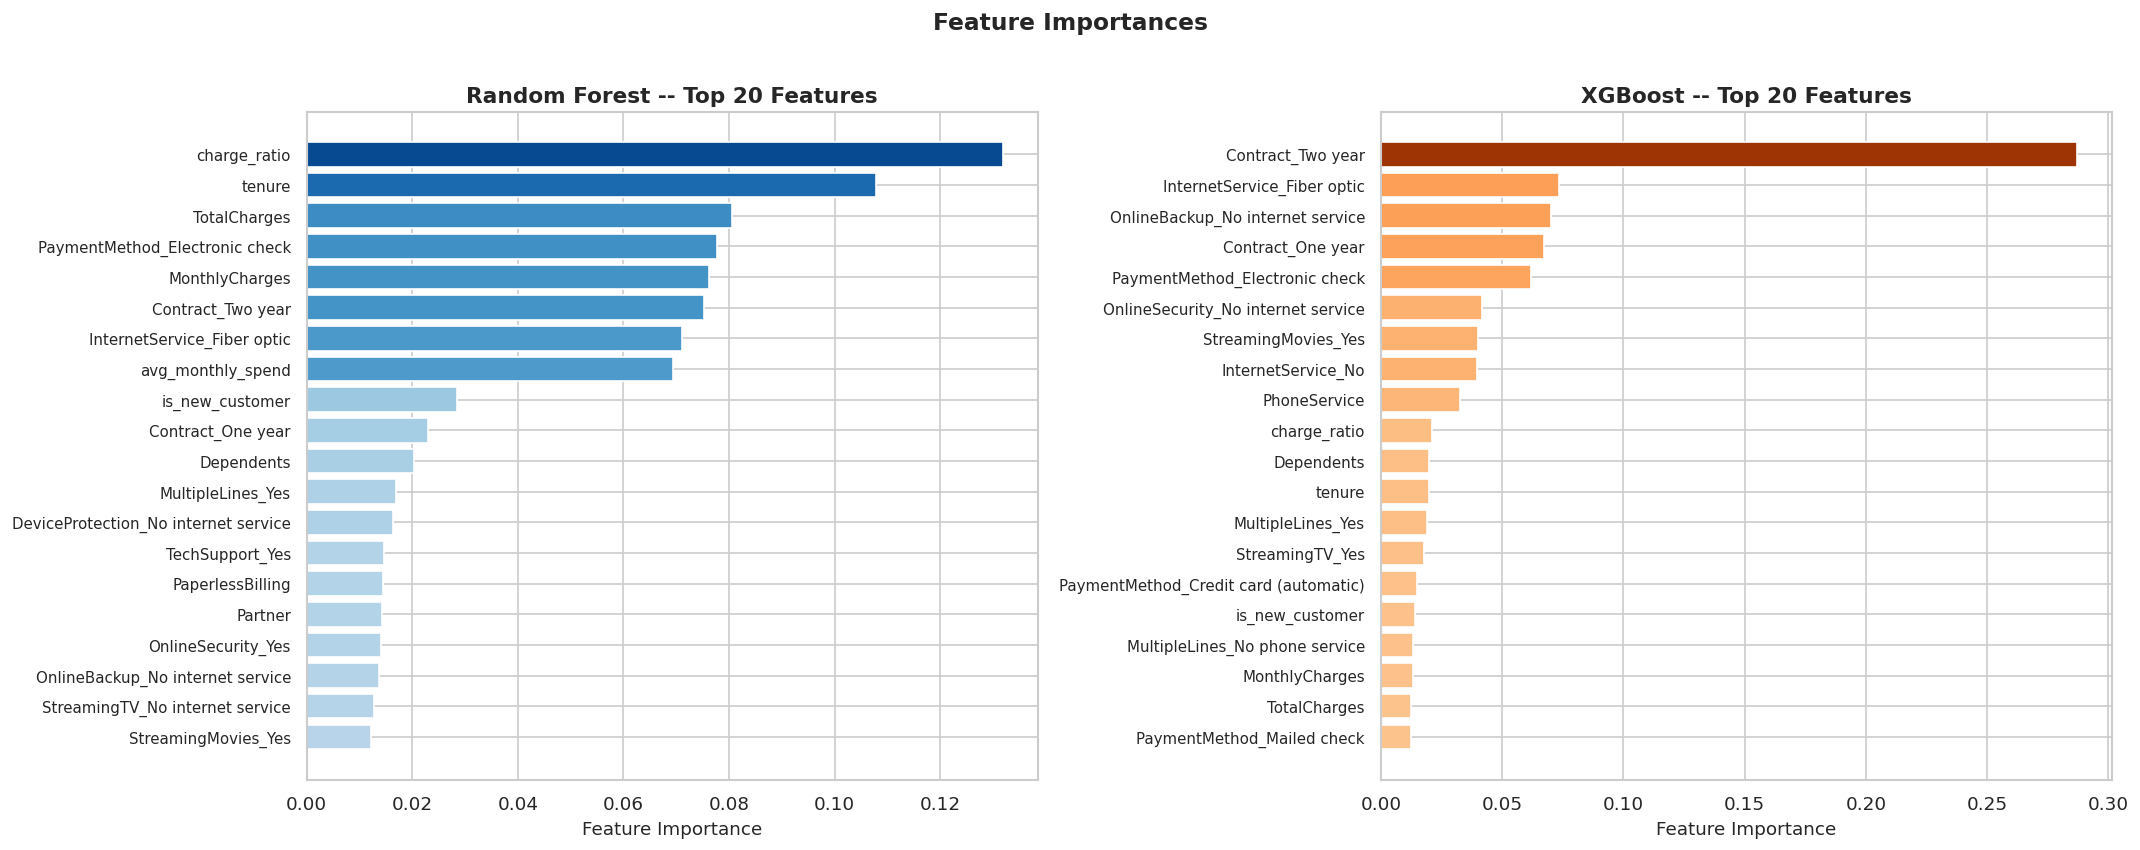

In [27]:
rf_model  = models_ml['Random Forest']
xgb_model = models_ml['XGBoost']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, model, title, cmap_name in [
    (axes[0], rf_model,  'Random Forest', 'Blues'),
    (axes[1], xgb_model, 'XGBoost',       'Oranges')
]:
    imp = pd.Series(model.feature_importances_, index=X_train_sm.columns)
    imp = imp.sort_values(ascending=True).tail(20)
    norm = (imp - imp.min()) / (imp.max() - imp.min() + 1e-9)
    bar_colors = getattr(plt.cm, cmap_name)(norm * 0.6 + 0.3)
    ax.barh(imp.index, imp.values, color=bar_colors, edgecolor='white')
    ax.set_title(f'{title} -- Top 20 Features', fontweight='bold')
    ax.set_xlabel('Feature Importance')
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('Feature Importances', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_importances.png', bbox_inches='tight')
plt.show()

Computing SHAP values (may take ~30 seconds)...


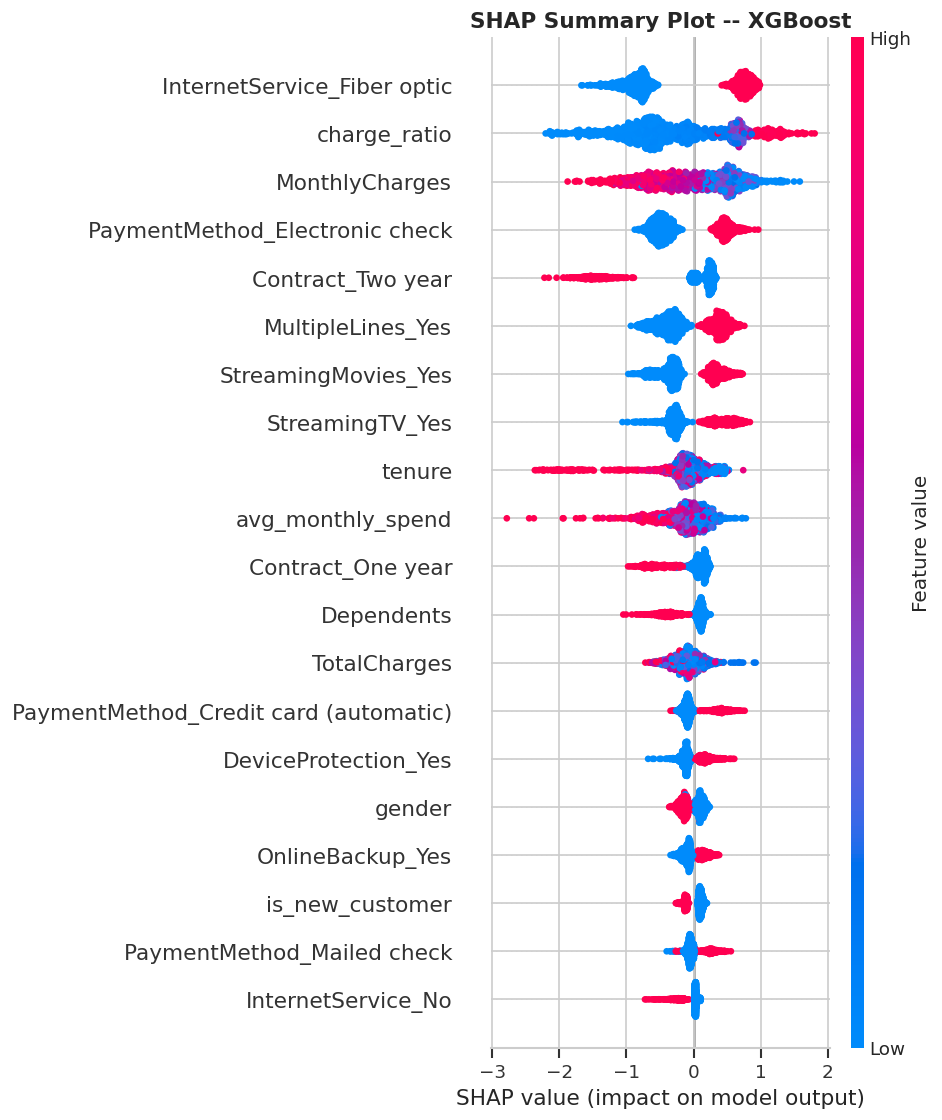

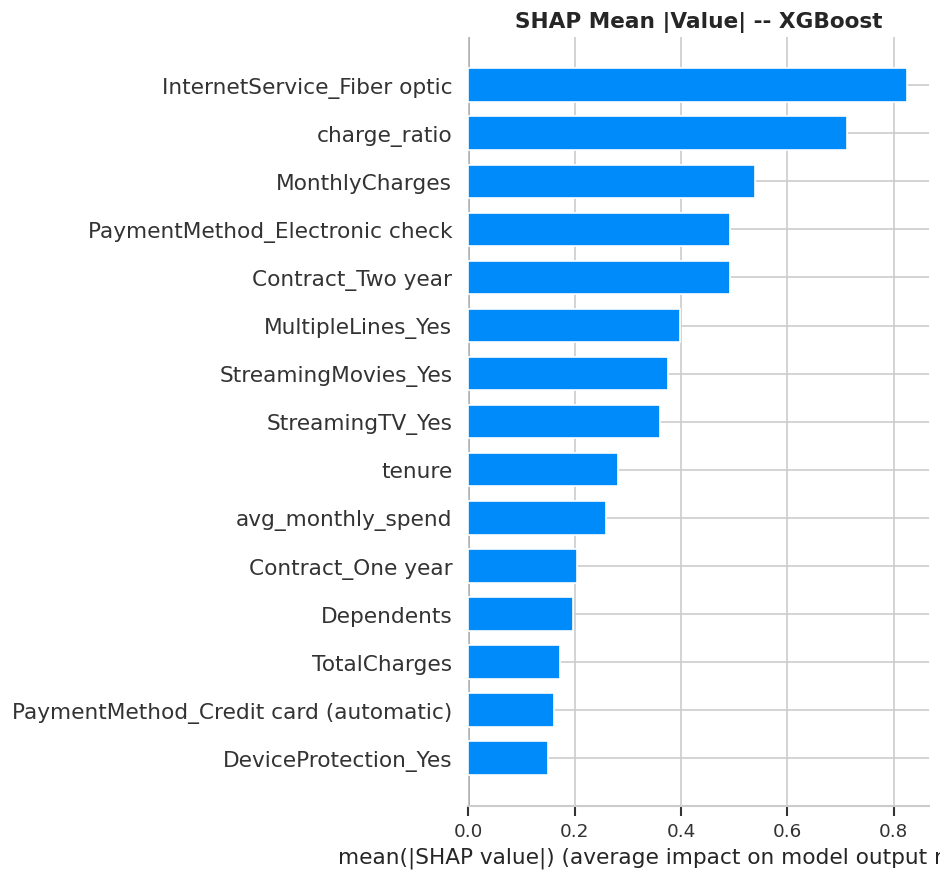

SHAP analysis complete.


In [28]:
print('Computing SHAP values (may take ~30 seconds)...')
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_fe)

plt.figure(figsize=(11, 8))
shap.summary_plot(shap_values, X_test_fe,
                  feature_names=X_test_fe.columns.tolist(),
                  plot_type='dot', show=False, max_display=20)
plt.title('SHAP Summary Plot -- XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_fe,
                  feature_names=X_test_fe.columns.tolist(),
                  plot_type='bar', show=False, max_display=15)
plt.title('SHAP Mean |Value| -- XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar.png', bbox_inches='tight')
plt.show()
print('SHAP analysis complete.')

Customer Risk Segmentation


In [29]:
best_ml_proba = results_ml.get(best_name, results_ml['Random Forest'])['y_proba']

seg_df = pd.DataFrame({
    'ChurnProbability': best_ml_proba,
    'ActualChurn'     : y_test.values
}, index=y_test.index)

def assign_risk(p):
    if p >= 0.75: return 'Critical'
    if p >= 0.50: return 'High'
    if p >= 0.25: return 'Medium'
    return 'Low'

seg_df['RiskTier'] = seg_df['ChurnProbability'].apply(assign_risk)

# Merge original attributes
seg_df = seg_df.merge(
    df_raw[['Contract', 'PaymentMethod', 'MonthlyCharges', 'tenure', 'InternetService']],
    left_index=True, right_index=True, how='left'
)

seg_summary = (
    seg_df.groupby('RiskTier')
    .agg(
        Customers=('ChurnProbability','count'),
        Actual_Churners=('ActualChurn','sum'),
        Avg_ChurnProb=('ChurnProbability','mean'),
        Avg_MonthlyCharges=('MonthlyCharges','mean'),
        Avg_Tenure=('tenure','mean')
    )
    .sort_values('Avg_ChurnProb', ascending=False)
)
seg_summary['Churn_Rate_pct'] = (
    seg_summary['Actual_Churners'] / seg_summary['Customers'] * 100
).round(1)
seg_summary['Revenue_at_Risk'] = (
    seg_summary['Customers'] * seg_summary['Avg_MonthlyCharges']
).round(0).astype(int)

print('Customer Risk Segmentation Summary:')
display(
    seg_summary.style
    .format({'Avg_ChurnProb': '{:.3f}', 'Avg_MonthlyCharges': '${:.2f}',
             'Avg_Tenure': '{:.1f}', 'Revenue_at_Risk': '${:,}'})
    .background_gradient(cmap='RdYlGn_r', subset=['Avg_ChurnProb','Churn_Rate_pct'])
)

Customer Risk Segmentation Summary:


,Customers,Actual_Churners,Avg_ChurnProb,Avg_MonthlyCharges,Avg_Tenure,Churn_Rate_pct,Revenue_at_Risk
RiskTier,,,,,,,
Critical,224,156,0.842,$78.00,7.5,69.600000,"$17,472"
High,307,122,0.624,$73.34,20.9,39.700000,"$22,517"
Medium,285,65,0.369,$72.20,32.3,22.800000,"$20,576"
Low,593,31,0.099,$50.15,46.7,5.200000,"$29,738"


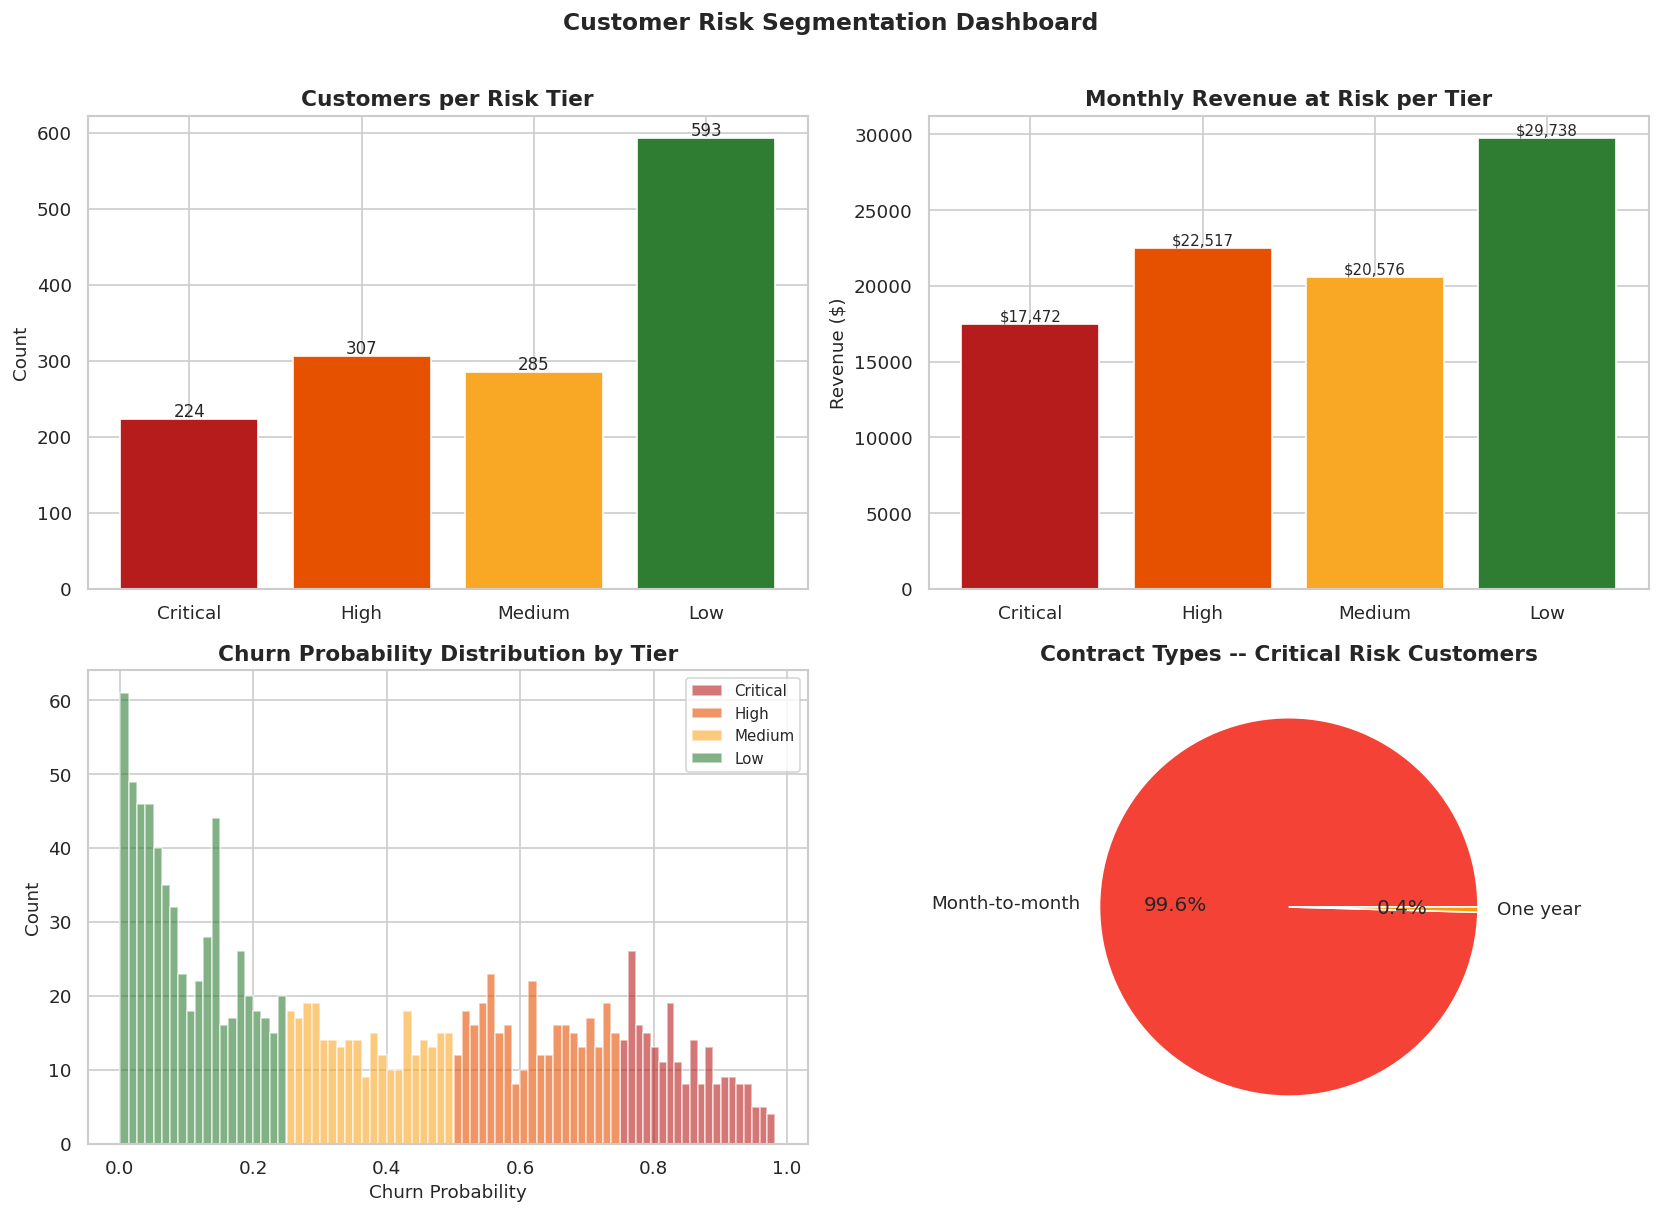


Top 15 highest-risk customers:


,ChurnProbability,RiskTier,Contract,MonthlyCharges,tenure,ActualChurn
809,0.982,Critical,Month-to-month,$69.55,1,1
2927,0.979,Critical,Month-to-month,$69.90,1,0
1739,0.979,Critical,Month-to-month,$69.90,1,1
1731,0.978,Critical,Month-to-month,$69.60,1,1
3682,0.970,Critical,Month-to-month,$69.10,1,1
4585,0.968,Critical,Month-to-month,$85.05,1,1
2194,0.965,Critical,Month-to-month,$79.50,1,1
6623,0.964,Critical,Month-to-month,$76.45,1,1
2464,0.962,Critical,Month-to-month,$77.15,1,1
6866,0.958,Critical,Month-to-month,$95.45,1,1


In [30]:
tier_order  = ['Critical', 'High', 'Medium', 'Low']
tier_colors = ['#B71C1C', '#E65100', '#F9A825', '#2E7D32']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

tier_counts = [seg_summary.loc[t, 'Customers'] if t in seg_summary.index else 0 for t in tier_order]
axes[0,0].bar(tier_order, tier_counts, color=tier_colors, edgecolor='white')
for i, v in enumerate(tier_counts):
    axes[0,0].text(i, v + 3, f'{v:,}', ha='center', fontsize=10)
axes[0,0].set_title('Customers per Risk Tier', fontweight='bold')
axes[0,0].set_ylabel('Count')

rev_risk = [seg_summary.loc[t,'Revenue_at_Risk'] if t in seg_summary.index else 0 for t in tier_order]
axes[0,1].bar(tier_order, rev_risk, color=tier_colors, edgecolor='white')
for i, v in enumerate(rev_risk):
    axes[0,1].text(i, v + 200, f'${v:,.0f}', ha='center', fontsize=9)
axes[0,1].set_title('Monthly Revenue at Risk per Tier', fontweight='bold')
axes[0,1].set_ylabel('Revenue ($)')

for tier, color in zip(tier_order, tier_colors):
    subset = seg_df[seg_df['RiskTier'] == tier]['ChurnProbability']
    if len(subset) > 0:
        subset.hist(bins=20, ax=axes[1,0], alpha=0.6, color=color, label=tier)
axes[1,0].set_title('Churn Probability Distribution by Tier', fontweight='bold')
axes[1,0].set_xlabel('Churn Probability')
axes[1,0].set_ylabel('Count')
axes[1,0].legend(fontsize=9)

crit = seg_df[seg_df['RiskTier'] == 'Critical']
if len(crit) > 0:
    crit_contract = crit['Contract'].value_counts()
    axes[1,1].pie(crit_contract, labels=crit_contract.index, autopct='%1.1f%%',
                  colors=['#F44336','#FF9800','#4CAF50'],
                  wedgeprops={'edgecolor':'white'})
    axes[1,1].set_title('Contract Types -- Critical Risk Customers', fontweight='bold')
else:
    axes[1,1].text(0.5, 0.5, 'No critical tier in test set',
                   ha='center', va='center', transform=axes[1,1].transAxes)

plt.suptitle('Customer Risk Segmentation Dashboard', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('risk_segmentation.png', bbox_inches='tight')
plt.show()

print('\nTop 15 highest-risk customers:')
display(
    seg_df.sort_values('ChurnProbability', ascending=False)
    [['ChurnProbability','RiskTier','Contract','MonthlyCharges','tenure','ActualChurn']]
    .head(15)
    .style.format({'ChurnProbability':'{:.3f}','MonthlyCharges':'${:.2f}'})
    .background_gradient(cmap='Reds', subset=['ChurnProbability'])
)

Retention Strategy Insights

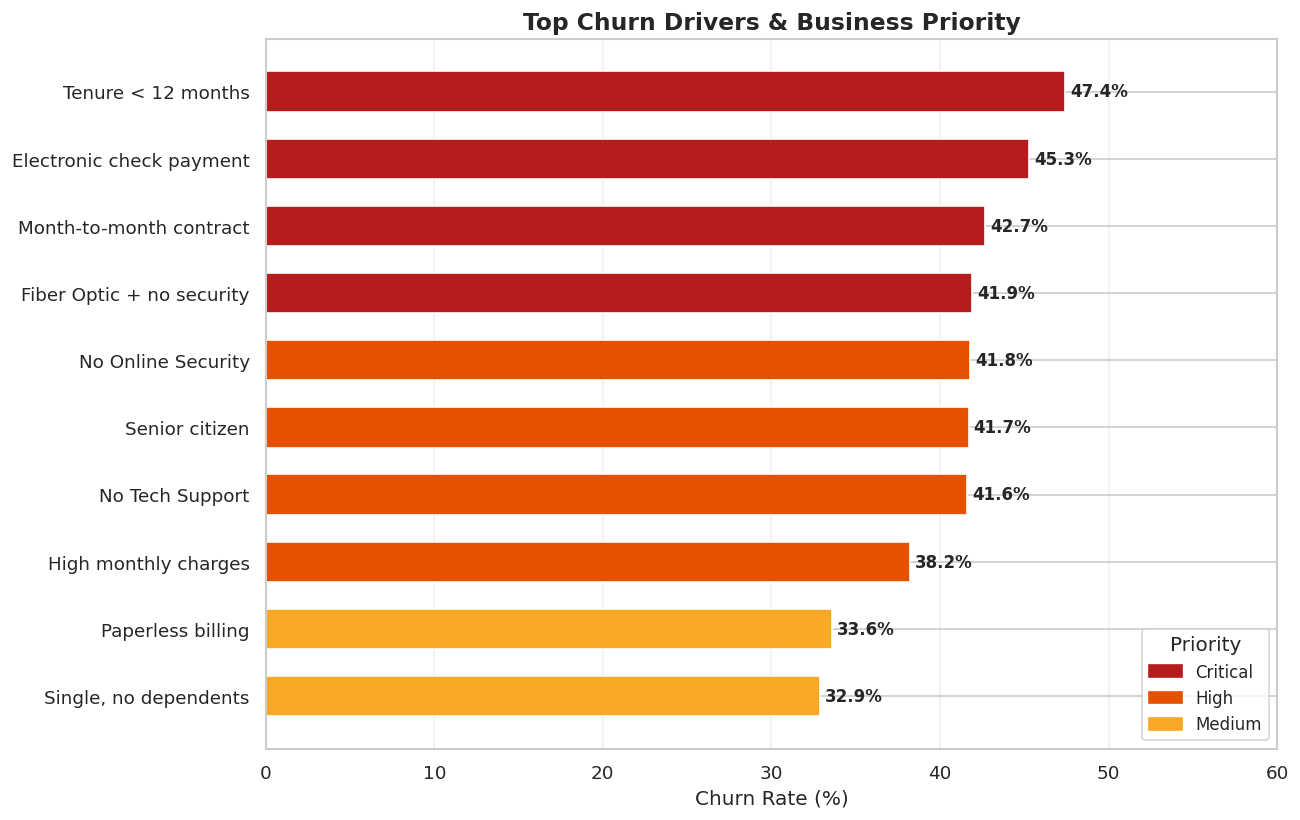

In [31]:
insights = pd.DataFrame([
    {'Driver': 'Month-to-month contract',    'Churn_Rate': 42.7, 'Priority': 'Critical'},
    {'Driver': 'Fiber Optic + no security',  'Churn_Rate': 41.9, 'Priority': 'Critical'},
    {'Driver': 'Electronic check payment',   'Churn_Rate': 45.3, 'Priority': 'Critical'},
    {'Driver': 'Senior citizen',             'Churn_Rate': 41.7, 'Priority': 'High'},
    {'Driver': 'Tenure < 12 months',         'Churn_Rate': 47.4, 'Priority': 'Critical'},
    {'Driver': 'No Tech Support',            'Churn_Rate': 41.6, 'Priority': 'High'},
    {'Driver': 'Paperless billing',          'Churn_Rate': 33.6, 'Priority': 'Medium'},
    {'Driver': 'No Online Security',         'Churn_Rate': 41.8, 'Priority': 'High'},
    {'Driver': 'Single, no dependents',      'Churn_Rate': 32.9, 'Priority': 'Medium'},
    {'Driver': 'High monthly charges',       'Churn_Rate': 38.2, 'Priority': 'High'},
])
color_map = {'Critical': '#B71C1C', 'High': '#E65100', 'Medium': '#F9A825'}
ins_sorted = insights.sort_values('Churn_Rate', ascending=True)

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(
    ins_sorted['Driver'], ins_sorted['Churn_Rate'],
    color=[color_map[p] for p in ins_sorted['Priority']],
    edgecolor='white', height=0.6
)
for bar, val in zip(bars, ins_sorted['Churn_Rate']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
patches = [mpatches.Patch(color=v, label=k) for k, v in color_map.items()]
ax.legend(handles=patches, title='Priority', fontsize=10, loc='lower right')
ax.set_xlabel('Churn Rate (%)', fontsize=12)
ax.set_title('Top Churn Drivers & Business Priority', fontsize=14, fontweight='bold')
ax.set_xlim(0, 60)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('retention_churn_drivers.png', bbox_inches='tight')
plt.show()

In [32]:
strategy = pd.DataFrame([
    {'Segment': 'New customers (<1yr)',      'Churn Risk': '~47%',
     'Strategy': 'Onboarding programme, 3-month loyalty discount, dedicated support',
     'Expected Impact': 'down 15% early churn'},
    {'Segment': 'Month-to-month contract',   'Churn Risk': '~43%',
     'Strategy': 'Offer 10-20% discount to switch to annual plan; highlight savings',
     'Expected Impact': 'down 30-40% in cohort'},
    {'Segment': 'Electronic check users',    'Churn Risk': '~45%',
     'Strategy': 'Incentivise autopay enrollment (e.g. $5/mo bill credit)',
     'Expected Impact': 'down 20% among converters'},
    {'Segment': 'Fiber Optic w/o security',  'Churn Risk': '~42%',
     'Strategy': 'Bundle OnlineSecurity + TechSupport free for 6 months',
     'Expected Impact': 'down 18% in Fiber segment'},
    {'Segment': 'Senior citizens',           'Churn Risk': '~42%',
     'Strategy': 'Dedicated senior support line, simplified billing, community plan',
     'Expected Impact': 'down 12% in senior segment'},
    {'Segment': 'Singles w/o dependents',    'Churn Risk': '~33%',
     'Strategy': 'Gamified loyalty points, referral rewards, social features',
     'Expected Impact': 'down 8% churn'},
])

print('CUSTOMER RETENTION STRATEGY PLAYBOOK')
print('=' * 65)
display(strategy.style
    .set_properties(**{'text-align':'left','font-size':'11px'})
    .hide(axis='index')
)

monthly_risk = (y_test == 1).sum() * df_raw['MonthlyCharges'].mean()
print(f'\nRevenue Impact Estimate:')
print(f'  Churners in test set       : {(y_test==1).sum():,}')
print(f'  Avg monthly charge         : ${df_raw["MonthlyCharges"].mean():.2f}')
print(f'  Monthly revenue at risk    : ${monthly_risk:,.2f}')
print(f'  If 30% retained -> ${monthly_risk*0.3:,.2f}/month saved')

CUSTOMER RETENTION STRATEGY PLAYBOOK


Segment,Churn Risk,Strategy,Expected Impact
New customers (<1yr),~47%,"Onboarding programme, 3-month loyalty discount, dedicated support",down 15% early churn
Month-to-month contract,~43%,Offer 10-20% discount to switch to annual plan; highlight savings,down 30-40% in cohort
Electronic check users,~45%,Incentivise autopay enrollment (e.g. $5/mo bill credit),down 20% among converters
Fiber Optic w/o security,~42%,Bundle OnlineSecurity + TechSupport free for 6 months,down 18% in Fiber segment
Senior citizens,~42%,"Dedicated senior support line, simplified billing, community plan",down 12% in senior segment
Singles w/o dependents,~33%,"Gamified loyalty points, referral rewards, social features",down 8% churn



Revenue Impact Estimate:
  Churners in test set       : 374
  Avg monthly charge         : $64.76
  Monthly revenue at risk    : $24,220.87
  If 30% retained -> $7,266.26/month saved


In [33]:
!pip freeze > requirements.txt